In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Load the uploaded CSV file
file_path = "cell_typepositionN.csv"
df = pd.read_csv(file_path)

# Display the first few rows to understand the structure
df.head()


,mcs,cellid,cellType,x,y
0,0,1,2,99.970149,99.970149
1,1,1,2,99.968750,100.000000
2,2,1,2,99.868852,99.950820
3,3,1,2,100.278689,99.836066
4,4,1,2,100.160714,99.928571


In [2]:
# Group the data by 'cellid' and extract the first and last coordinates
start_positions = df.sort_values('mcs').groupby('cellid').first()[['x', 'y']]
end_positions = df.sort_values('mcs').groupby('cellid').last()[['x', 'y']]

# Compute Euclidean distance between start and end positions
distances = np.sqrt((end_positions['x'] - start_positions['x'])**2 + 
                    (end_positions['y'] - start_positions['y'])**2)

# Create a result DataFrame
distance_df = pd.DataFrame({
    'cellid': distances.index,
    'start_x': start_positions['x'].values,
    'start_y': start_positions['y'].values,
    'end_x': end_positions['x'].values,
    'end_y': end_positions['y'].values,
    'euclidean_distance': distances.values
})

# Display the result
#import ace_tools as tools; tools.display_dataframe_to_user(name="Cell Movement Distances", dataframe=distance_df)

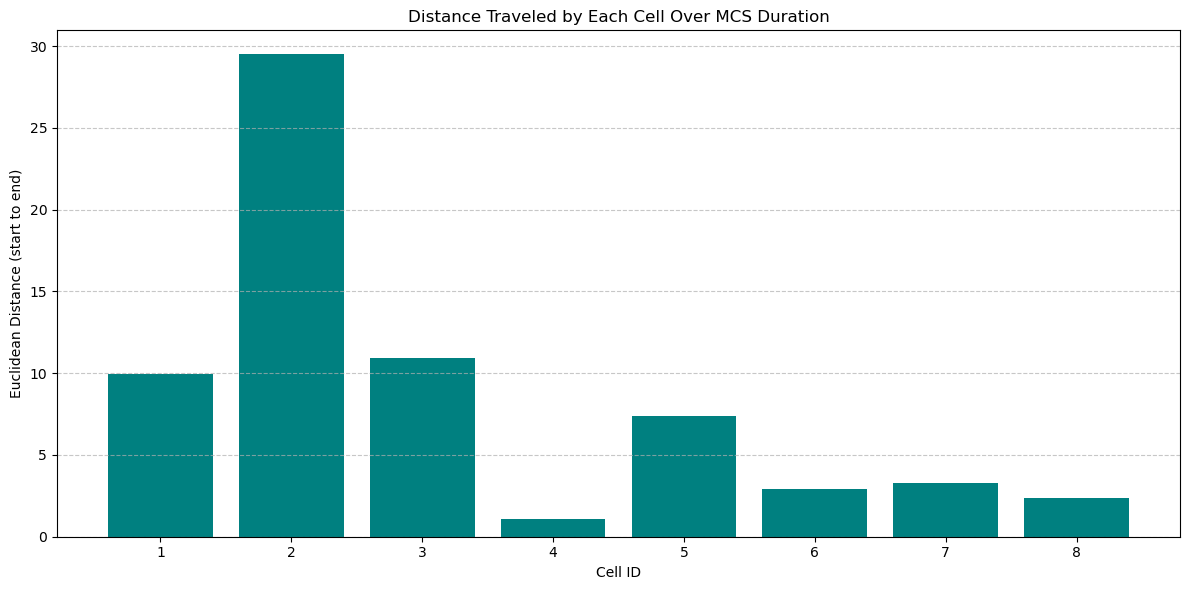

In [3]:
# Group by cellid to get first and last positions
start_pos = df.groupby('cellid').first()
end_pos = df.groupby('cellid').last()

# Compute Euclidean distance for each cell from start to end
distances = np.sqrt((end_pos['x'] - start_pos['x'])**2 + (end_pos['y'] - start_pos['y'])**2)

# Create a DataFrame for plotting
distance_df = pd.DataFrame({
    'cellid': distances.index,
    'euclidean_distance': distances.values
})

# Plot
plt.figure(figsize=(12, 6))
plt.bar(distance_df['cellid'], distance_df['euclidean_distance'], color='teal')
plt.xlabel('Cell ID')
plt.ylabel('Euclidean Distance (start to end)')
plt.title('Distance Traveled by Each Cell Over MCS Duration')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("data1.png", dpi = 500, bbox_inches='tight')
plt.show()


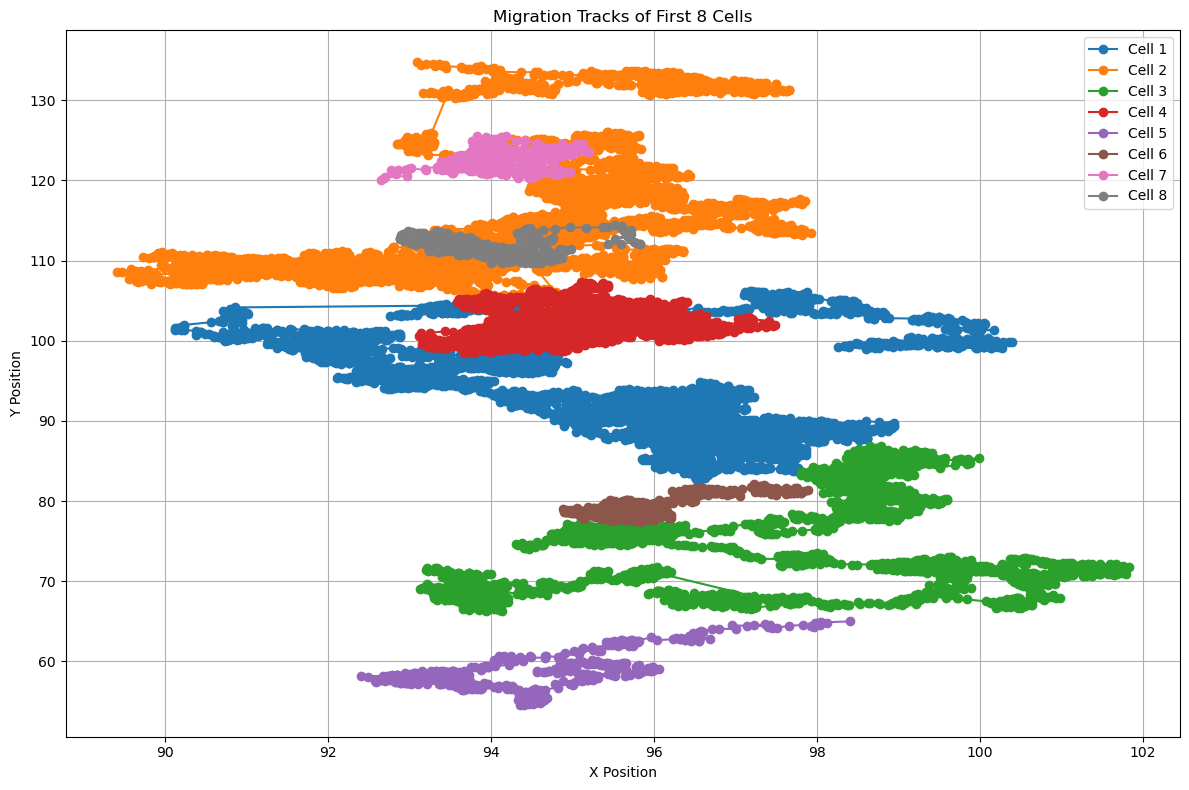

In [4]:
# Get unique cell IDs and select the first 8
first_8_cellids = df['cellid'].unique()[:8]

# Filter data for those 8 cell IDs
df_subset = df[df['cellid'].isin(first_8_cellids)]

# Plot migration tracks
plt.figure(figsize=(12, 8))
for cell_id in first_8_cellids:
    cell_data = df_subset[df_subset['cellid'] == cell_id]
    plt.plot(cell_data['x'], cell_data['y'], marker='o', label=f'Cell {cell_id}')

plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.title('Migration Tracks of First 8 Cells')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("data2.png", dpi = 500, bbox_inches='tight')
plt.show()


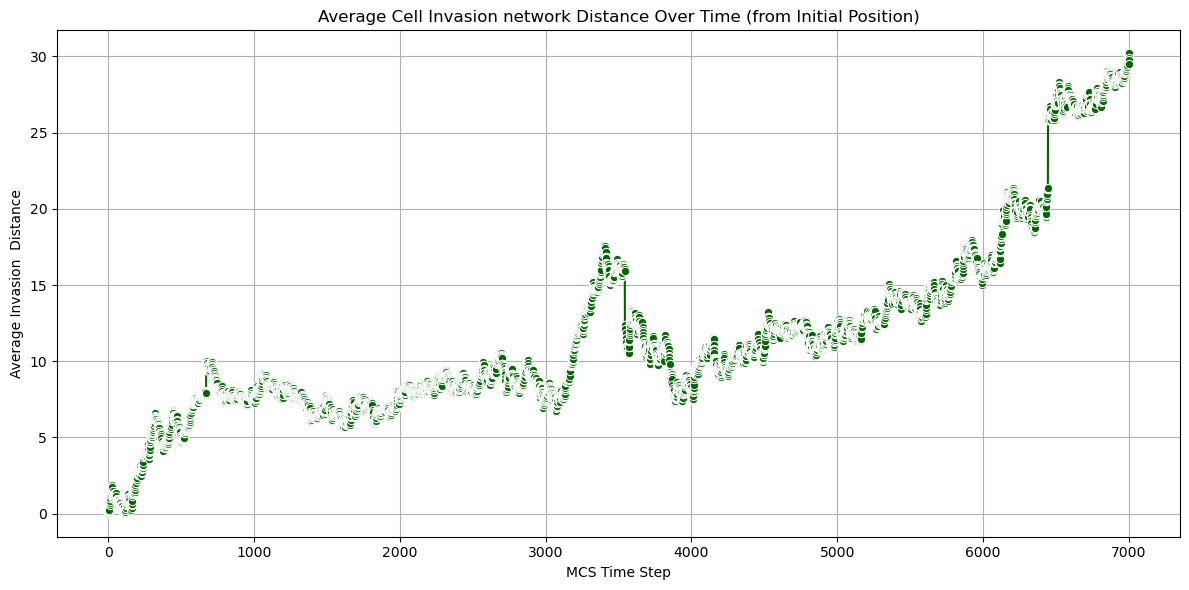

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load the data

# Get initial position of each cell at its first MCS
initial_positions = df.groupby('cellid').first()[['x', 'y']]

# Merge initial positions back to the full dataframe
df = df.merge(initial_positions, left_on='cellid', right_index=True, suffixes=('', '_initial'))

# Compute Euclidean distance from initial position at each MCS
df['distance_from_start'] = np.sqrt(
    (df['x'] - df['x_initial'])**2 + (df['y'] - df['y_initial'])**2
)

# Aggregate (e.g., mean distance) across all cells per MCS time step
#avg_distance_per_mcs = df.groupby('mcs')['distance_from_start'].mean().reset_index()
avg_distance_per_mcs = df.groupby('mcs')['distance_from_start'].max().reset_index()
avg_distance_per_mcs['distance_times'] = avg_distance_per_mcs['distance_from_start'] * 2
# Plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=avg_distance_per_mcs, x='mcs', y='distance_from_start', marker='o', color='darkgreen')
plt.xlabel('MCS Time Step')
plt.ylabel('Average Invasion  Distance')
plt.title('Average Cell Invasion network Distance Over Time (from Initial Position)')
plt.grid(True)
plt.tight_layout()
plt.savefig("data3.png", dpi = 500, bbox_inches='tight')
plt.show()


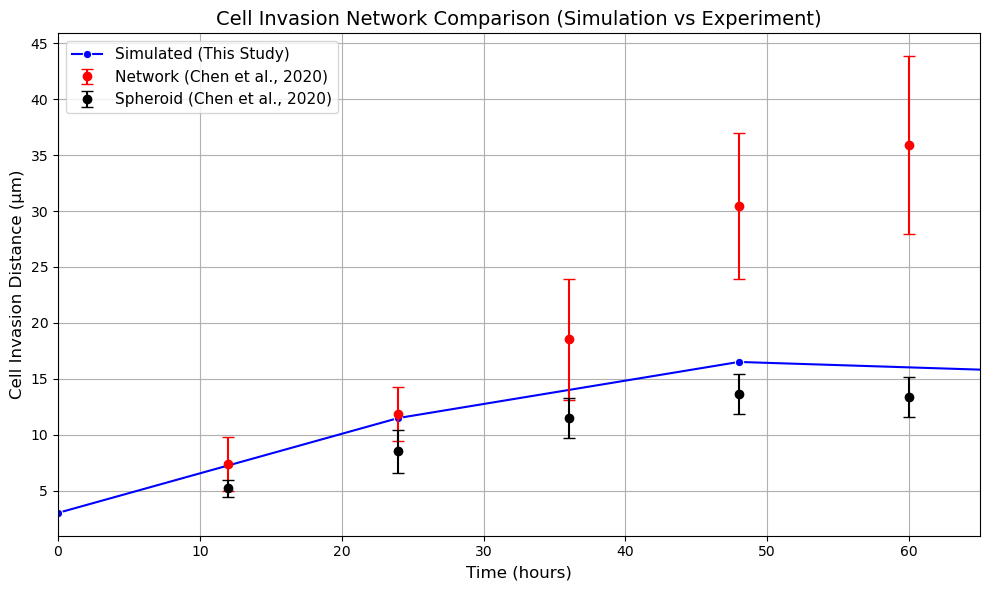

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load your simulation data
df = pd.read_csv('cell_typepositionN.csv')

# Calculate initial position of each cell
initial_positions = df.groupby('cellid').first()[['x', 'y']]
df = df.merge(initial_positions, left_on='cellid', right_index=True, suffixes=('', '_initial'))

# Euclidean distance from initial position at each MCS
df['distance_from_start'] = np.sqrt(
    (df['x'] - df['x_initial'])**2 + (df['y'] - df['y_initial'])**2
)

# Convert MCS to hours: 1000 MCS = 24 hrs → 1 MCS = 0.024 hrs
df['time_hr'] = df['mcs'] * 0.024

# Round time to the nearest 12-hour interval
df['time_hr_rounded'] = df['time_hr'].round()  # for grouping
df = df[df['time_hr_rounded'] % 12 == 0]       # filter to 12-hr intervals

# Compute mean invasion distance at each 12-hour interval
avg_dist_per_time = df.groupby('time_hr_rounded')['distance_from_start'].max().reset_index()
avg_dist_per_time = avg_dist_per_time[avg_dist_per_time['time_hr_rounded'] <= 60]  # match Chen data
avg_dist_per_time = avg_dist_per_time[avg_dist_per_time['time_hr_rounded'] <= 60] * 2
# PLOT: Overlay simulation and experimental data
plt.figure(figsize=(10, 6))

# # Plot simulation data
sns.lineplot(
    data=avg_dist_per_time, 
    x='time_hr_rounded', 
    y='distance_from_start', 
    marker='o', 
    label='Simulated (This Study)', 
    color='blue'
)




# Experimental Network data
network_days = [12, 24, 36, 48, 60]
network_conc = [7.41, 11.88, 18.53, 30.42, 35.91]
network_error = [2.43, 2.43, 5.37, 6.52, 7.92]
plt.errorbar(
    network_days, network_conc, yerr=network_error, color='red',
    fmt='o', capsize=4, label='Network (Chen et al., 2020)'
)

# Experimental Spheroid data
spheroid_days = [12, 24, 36, 48, 60]
spheroid_conc = [5.24, 8.56, 11.50, 13.67, 13.42]
spheroid_error = [0.77, 1.92, 1.79, 1.79, 1.79]
plt.errorbar(
    spheroid_days, spheroid_conc, yerr=spheroid_error, color='black',
    fmt='o', capsize=4, label='Spheroid (Chen et al., 2020)'
)

# Final plot formatting
plt.xlabel('Time (hours)', fontsize=12)
plt.ylabel('Cell Invasion Distance (μm)', fontsize=12)
plt.title('Cell Invasion Network Comparison (Simulation vs Experiment)', fontsize=14)
plt.xlim(0, 65)
plt.legend(loc='best', fontsize=11)
plt.grid(True)
plt.tight_layout()
plt.savefig("cell_invasion_simulation_vs_experiment.png", dpi=500)
plt.savefig("data4.png", dpi = 500, bbox_inches='tight')
plt.show()


###### SPHEROID

In [7]:
# Load the uploaded CSV file
file_path = "cell_typepositionS.csv"
df = pd.read_csv(file_path)

# Display the first few rows to understand the structure
df.head()


,mcs,cellid,cellType,x,y
0,0,1,1,100.030769,100.076923
1,1,1,1,100.030769,100.076923
2,2,1,1,100.111111,100.190476
3,3,1,1,99.935484,100.064516
4,4,1,1,99.721311,100.131148


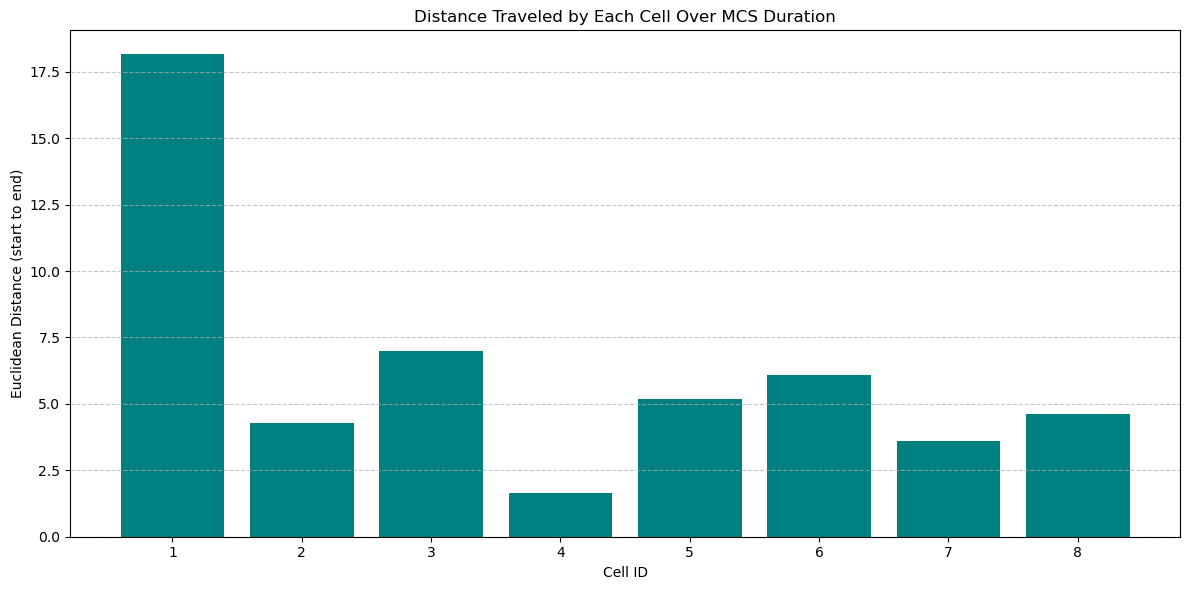

In [8]:
# Group by cellid to get first and last positions
start_pos = df.groupby('cellid').first()
end_pos = df.groupby('cellid').last()

# Compute Euclidean distance for each cell from start to end
distances = np.sqrt((end_pos['x'] - start_pos['x'])**2 + (end_pos['y'] - start_pos['y'])**2)

# Create a DataFrame for plotting
distance_df = pd.DataFrame({
    'cellid': distances.index,
    'euclidean_distance': distances.values
})

# Plot
plt.figure(figsize=(12, 6))
plt.bar(distance_df['cellid'], distance_df['euclidean_distance'], color='teal')
plt.xlabel('Cell ID')
plt.ylabel('Euclidean Distance (start to end)')
plt.title('Distance Traveled by Each Cell Over MCS Duration')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("data5.png", dpi = 500, bbox_inches='tight')
plt.show()


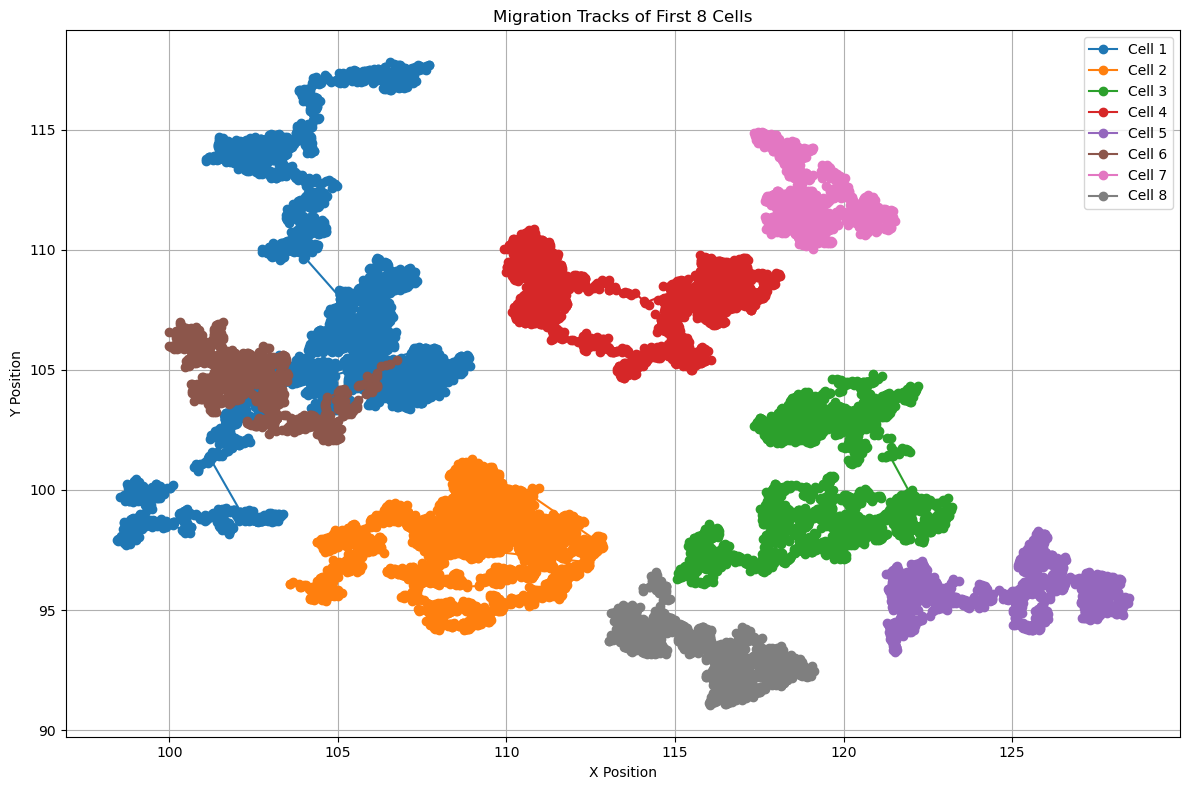

In [9]:
# Get unique cell IDs and select the first 8
first_8_cellids = df['cellid'].unique()[:8]

# Filter data for those 8 cell IDs
df_subset = df[df['cellid'].isin(first_8_cellids)]

# Plot migration tracks
plt.figure(figsize=(12, 8))
for cell_id in first_8_cellids:
    cell_data = df_subset[df_subset['cellid'] == cell_id]
    plt.plot(cell_data['x'], cell_data['y'], marker='o', label=f'Cell {cell_id}')

plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.title('Migration Tracks of First 8 Cells')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("data6.png", dpi = 500, bbox_inches='tight')
plt.show()


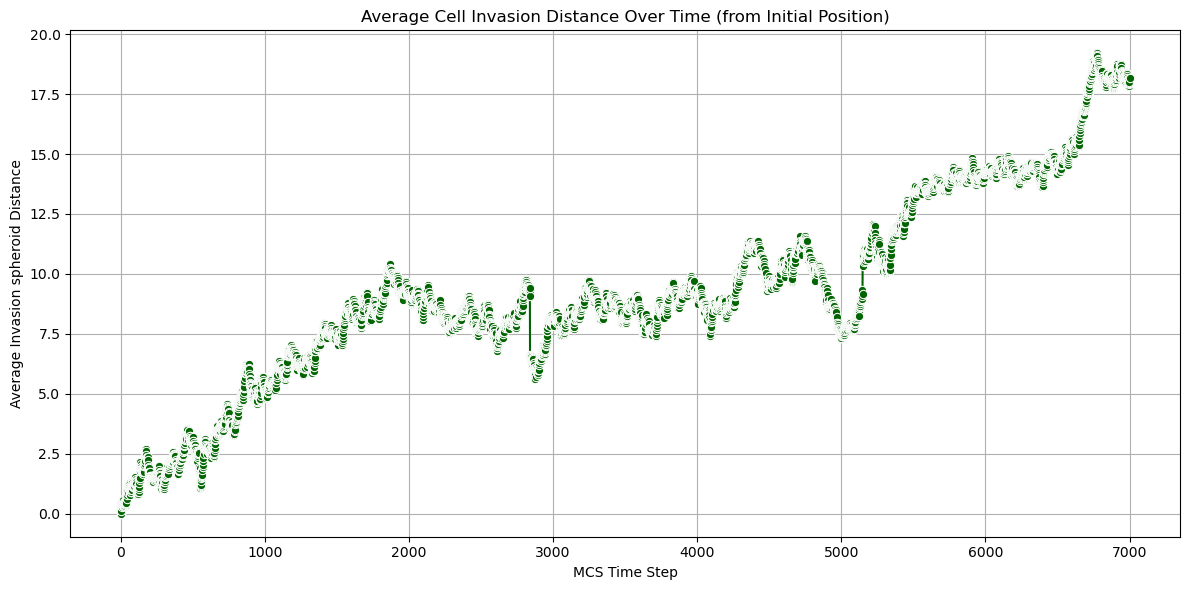

In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load the data

# Get initial position of each cell at its first MCS
initial_positions = df.groupby('cellid').first()[['x', 'y']]

# Merge initial positions back to the full dataframe
df = df.merge(initial_positions, left_on='cellid', right_index=True, suffixes=('', '_initial'))

# Compute Euclidean distance from initial position at each MCS
df['distance_from_start'] = np.sqrt(
    (df['x'] - df['x_initial'])**2 + (df['y'] - df['y_initial'])**2
)

# Aggregate (e.g., mean distance) across all cells per MCS time step
#avg_distance_per_mcs = df.groupby('mcs')['distance_from_start'].mean().reset_index()
avg_distance_per_mcs = df.groupby('mcs')['distance_from_start'].max().reset_index()
avg_distance_per_mcs['distance_times'] = avg_distance_per_mcs['distance_from_start'] * 2
# Plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=avg_distance_per_mcs, x='mcs', y='distance_from_start', marker='o', color='darkgreen')
plt.xlabel('MCS Time Step')
plt.ylabel('Average Invasion spheroid Distance')
plt.title('Average Cell Invasion Distance Over Time (from Initial Position)')
plt.grid(True)
plt.tight_layout()
plt.savefig("data7.png", dpi = 500, bbox_inches='tight')
plt.show()


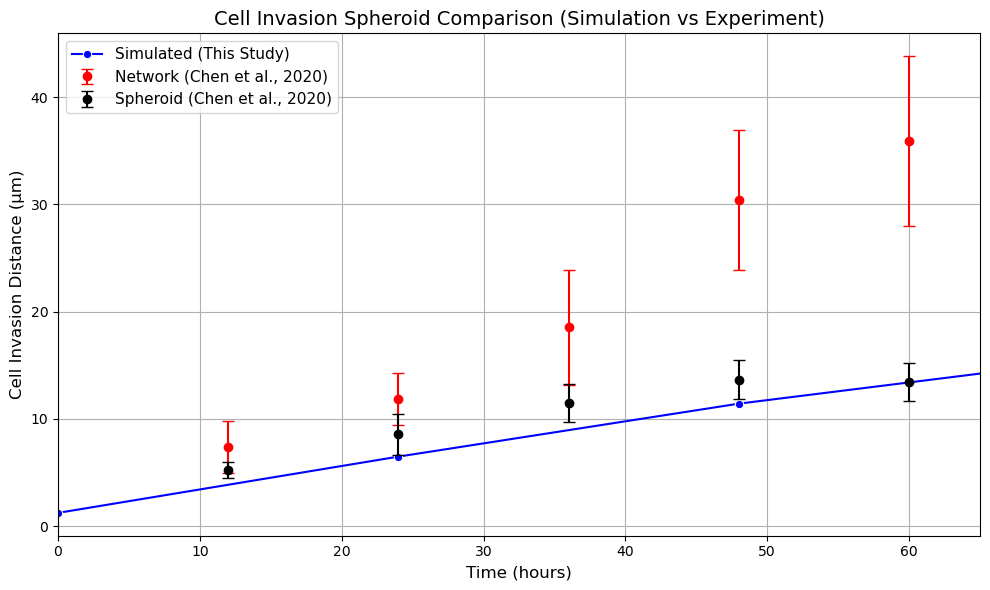

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load your simulation data
df = pd.read_csv('cell_typepositionS.csv')

# Calculate initial position of each cell
initial_positions = df.groupby('cellid').first()[['x', 'y']]
df = df.merge(initial_positions, left_on='cellid', right_index=True, suffixes=('', '_initial'))

# Euclidean distance from initial position at each MCS
df['distance_from_start'] = np.sqrt(
    (df['x'] - df['x_initial'])**2 + (df['y'] - df['y_initial'])**2
)

# Convert MCS to hours: 1000 MCS = 24 hrs → 1 MCS = 0.024 hrs
df['time_hr'] = df['mcs'] * 0.024

# Round time to the nearest 12-hour interval
df['time_hr_rounded'] = df['time_hr'].round()  # for grouping
df = df[df['time_hr_rounded'] % 12 == 0]       # filter to 12-hr intervals

# Compute mean invasion distance at each 12-hour interval
avg_dist_per_time = df.groupby('time_hr_rounded')['distance_from_start'].max().reset_index()
avg_dist_per_time = avg_dist_per_time[avg_dist_per_time['time_hr_rounded'] <= 60]  # match Chen data
avg_dist_per_time = avg_dist_per_time[avg_dist_per_time['time_hr_rounded'] <= 60] * 2
# PLOT: Overlay simulation and experimental data
plt.figure(figsize=(10, 6))

# Plot simulation data
sns.lineplot(
    data=avg_dist_per_time, 
    x='time_hr_rounded', 
    y='distance_from_start', 
    marker='o', 
    label='Simulated (This Study)', 
    color='blue'
)

# Experimental Network data
network_days = [12, 24, 36, 48, 60]
network_conc = [7.41, 11.88, 18.53, 30.42, 35.91]
network_error = [2.43, 2.43, 5.37, 6.52, 7.92]
plt.errorbar(
    network_days, network_conc, yerr=network_error, color='red',
    fmt='o', capsize=4, label='Network (Chen et al., 2020)'
)

# Experimental Spheroid data
spheroid_days = [12, 24, 36, 48, 60]
spheroid_conc = [5.24, 8.56, 11.50, 13.67, 13.42]
spheroid_error = [0.77, 1.92, 1.79, 1.79, 1.79]
plt.errorbar(
    spheroid_days, spheroid_conc, yerr=spheroid_error, color='black',
    fmt='o', capsize=4, label='Spheroid (Chen et al., 2020)'
)

# Final plot formatting
plt.xlabel('Time (hours)', fontsize=12)
plt.ylabel('Cell Invasion Distance (μm)', fontsize=12)
plt.title('Cell Invasion Spheroid Comparison (Simulation vs Experiment)', fontsize=14)
plt.xlim(0, 65)
plt.legend(loc='best', fontsize=11)
plt.grid(True)
plt.tight_layout()
#plt.savefig("cell_invasion_simulation_s_vs_experiment.png", dpi=500)
plt.savefig("data8.png", dpi = 500, bbox_inches='tight')
plt.show()


####  Spheroid

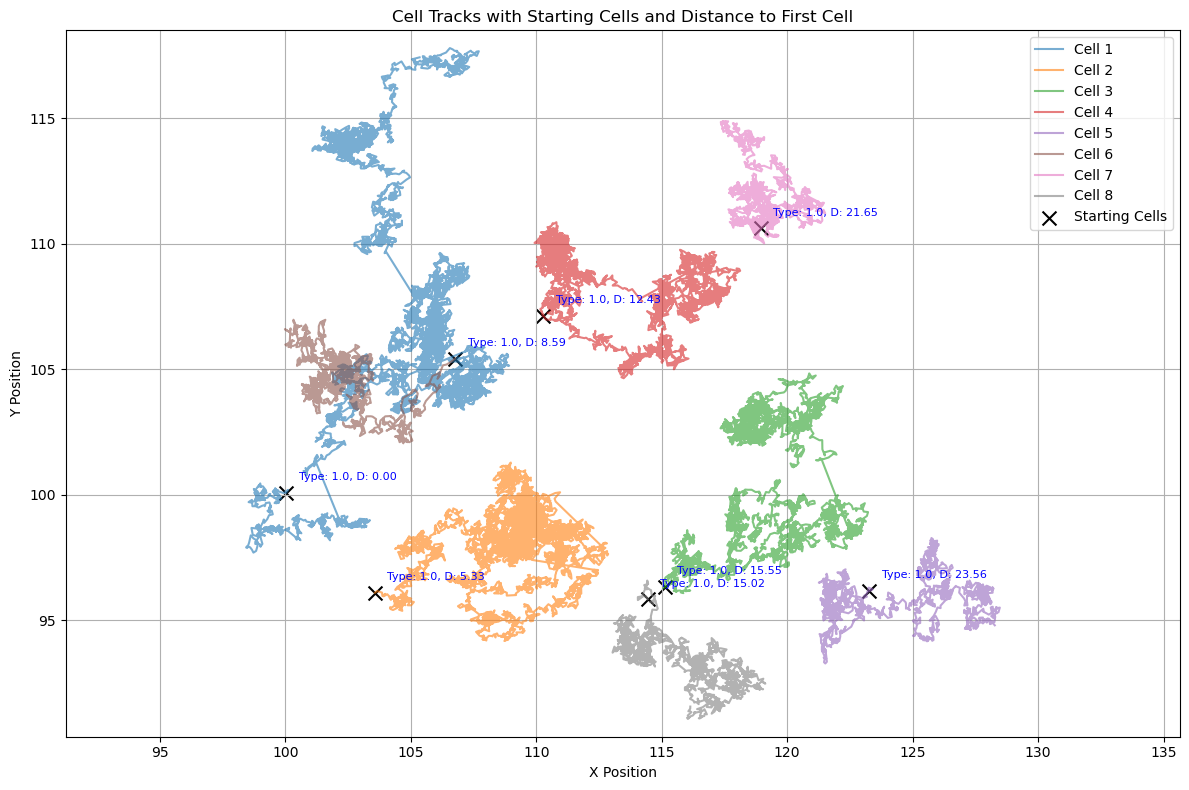

In [12]:
# Load the newly uploaded dataset
file_path = "cell_typepositionS.csv"
df = pd.read_csv(file_path)

# Sort the dataframe
df_sorted = df.sort_values(['cellid', 'mcs'])

# Get initial appearances for each cell
initial_appearances = df_sorted.groupby('cellid').first().reset_index()

# Create a base plot
plt.figure(figsize=(12, 8))

# Plot cell tracks
for cell_id in df_sorted['cellid'].unique():
    cell_data = df_sorted[df_sorted['cellid'] == cell_id]
    plt.plot(cell_data['x'], cell_data['y'], alpha=0.6, label=f'Cell {cell_id}')

# Mark initial positions with black 'X'
plt.scatter(initial_appearances['x'], initial_appearances['y'], color='black', marker='x', s=100, label='Starting Cells')

# Use the first cell's position as the reference
ref_x = initial_appearances.iloc[0]['x']
ref_y = initial_appearances.iloc[0]['y']

# Compute Euclidean distance to this reference point for each starting cell
initial_appearances['distance_to_first'] = np.sqrt(
    (initial_appearances['x'] - ref_x)**2 +
    (initial_appearances['y'] - ref_y)**2
)

# Annotate the starting cells with cellType and distance
for _, row in initial_appearances.iterrows():
    plt.text(row['x'] + 0.5, row['y'] + 0.5,
             f'Type: {row["cellType"]}, D: {row["distance_to_first"]:.2f}',
             fontsize=8, color='blue')

plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.title('Cell Tracks with Starting Cells and Distance to First Cell')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.tight_layout()
plt.show()

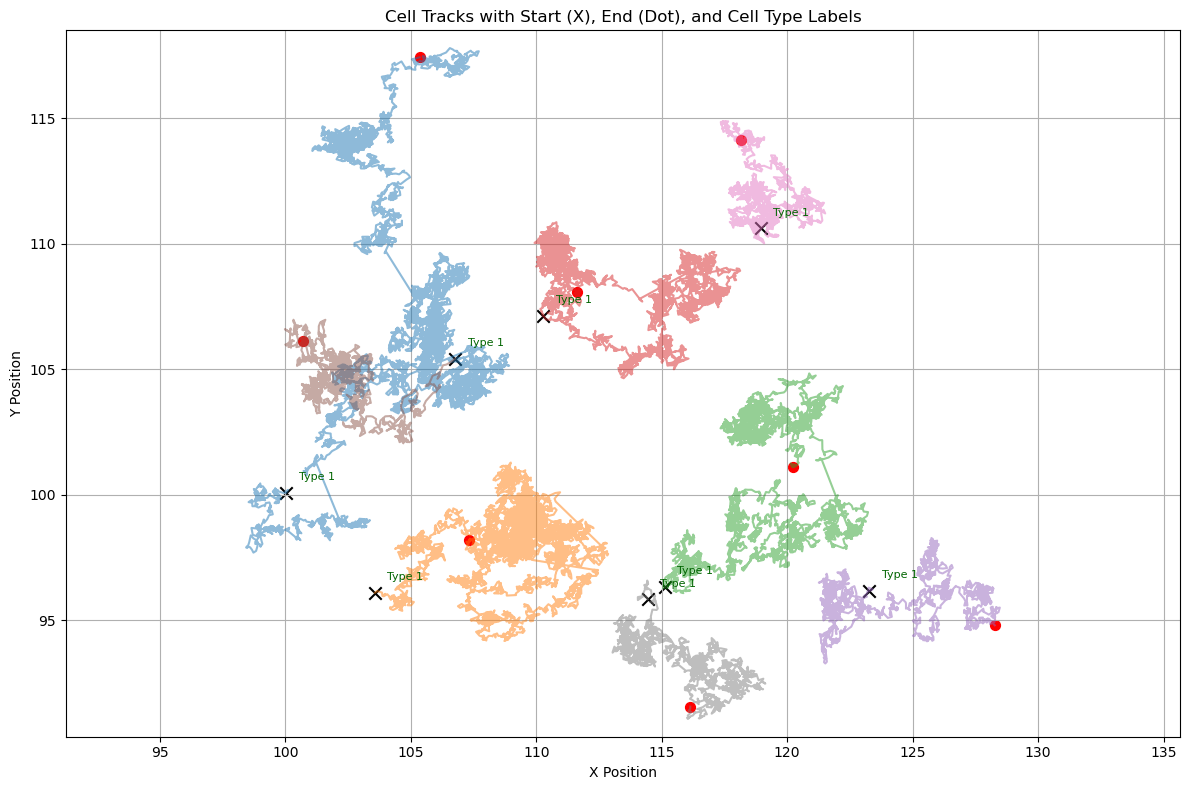

In [13]:
# Load the latest uploaded dataset
file_path = "cell_typepositionS.csv"
df = pd.read_csv(file_path)

# Sort the data by cellid and mcs
df_sorted = df.sort_values(['cellid', 'mcs'])

# Get starting and ending positions for each cell
start_positions = df_sorted.groupby('cellid').first().reset_index()
end_positions = df_sorted.groupby('cellid').last().reset_index()

# Create the plot
plt.figure(figsize=(12, 8))

# Plot trajectories and mark start (X), end (dot), and annotate with cell type
for cell_id in df_sorted['cellid'].unique():
    cell_data = df_sorted[df_sorted['cellid'] == cell_id]
    cell_type = cell_data['cellType'].iloc[0]

    # Plot trajectory
    plt.plot(cell_data['x'], cell_data['y'], alpha=0.5)

    # Plot start point with X and label with cell type
    start = start_positions[start_positions['cellid'] == cell_id]
    plt.scatter(start['x'], start['y'], color='black', marker='x', s=80)
    plt.text(start['x'].values[0] + 0.5, start['y'].values[0] + 0.5,
             f'Type {cell_type}', fontsize=8, color='darkgreen')

    # Plot end point with red dot
    end = end_positions[end_positions['cellid'] == cell_id]
    plt.scatter(end['x'], end['y'], color='red', s=50)

# Add labels and styling
plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.title('Cell Tracks with Start (X), End (Dot), and Cell Type Labels')
plt.grid(True)
plt.axis('equal')
plt.tight_layout()
plt.show()

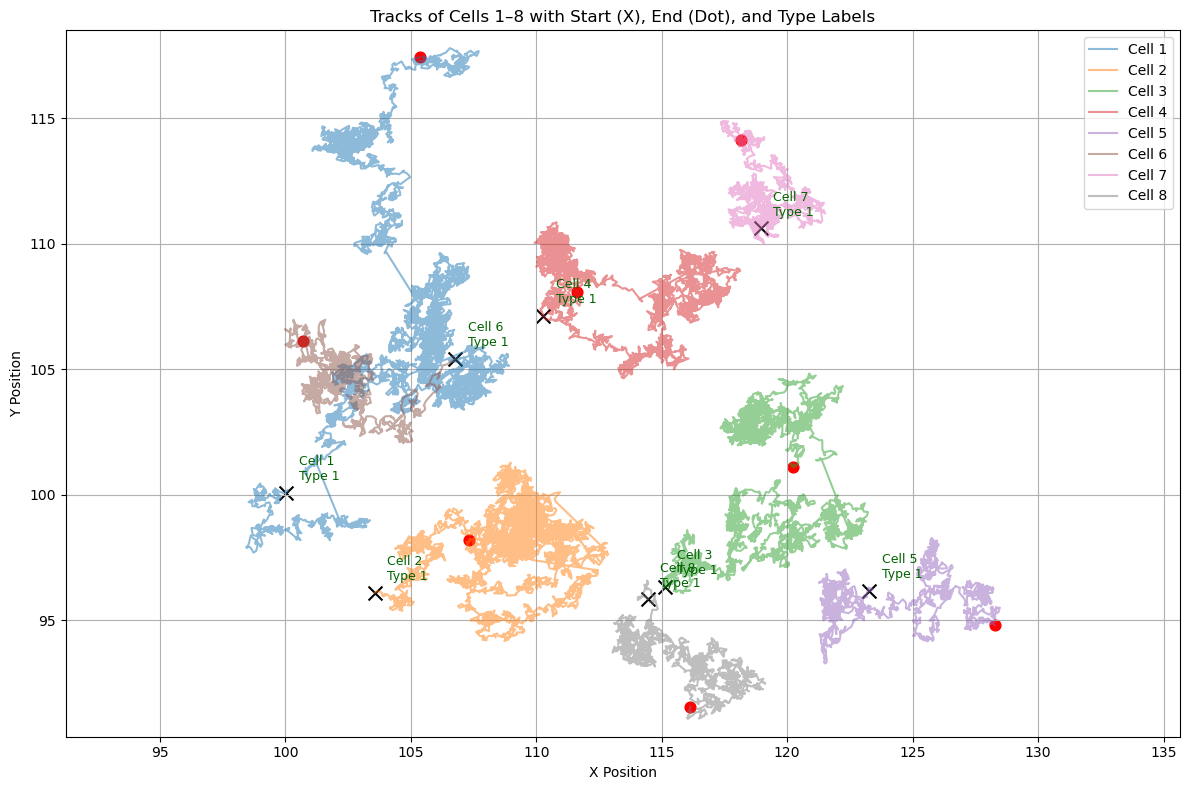

In [14]:
# Filter the first 8 unique cells
unique_cell_ids = df_sorted['cellid'].unique()[:8]

# Extract their start and end positions
start_positions = df_sorted[df_sorted['cellid'].isin(unique_cell_ids)].groupby('cellid').first().reset_index()
end_positions = df_sorted[df_sorted['cellid'].isin(unique_cell_ids)].groupby('cellid').last().reset_index()

# Create the plot
plt.figure(figsize=(12, 8))

# Loop over each cell id
for i, cell_id in enumerate(unique_cell_ids, start=1):
    cell_data = df_sorted[df_sorted['cellid'] == cell_id]
    cell_type = cell_data['cellType'].iloc[0]

    # Plot cell trajectory
    plt.plot(cell_data['x'], cell_data['y'], alpha=0.5, label=f'Cell {i}')

    # Starting point with black 'X'
    start_x, start_y = cell_data.iloc[0][['x', 'y']]
    plt.scatter(start_x, start_y, color='black', marker='x', s=100)
    plt.text(start_x + 0.5, start_y + 0.5, f'Cell {i}\nType {cell_type}', fontsize=9, color='darkgreen')

    # End point with red dot
    end_x, end_y = cell_data.iloc[-1][['x', 'y']]
    plt.scatter(end_x, end_y, color='red', s=60)

# Final plot formatting
plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.title('Tracks of Cells 1–8 with Start (X), End (Dot), and Type Labels')
plt.grid(True)
plt.axis('equal')
plt.legend()
plt.tight_layout()
plt.show()

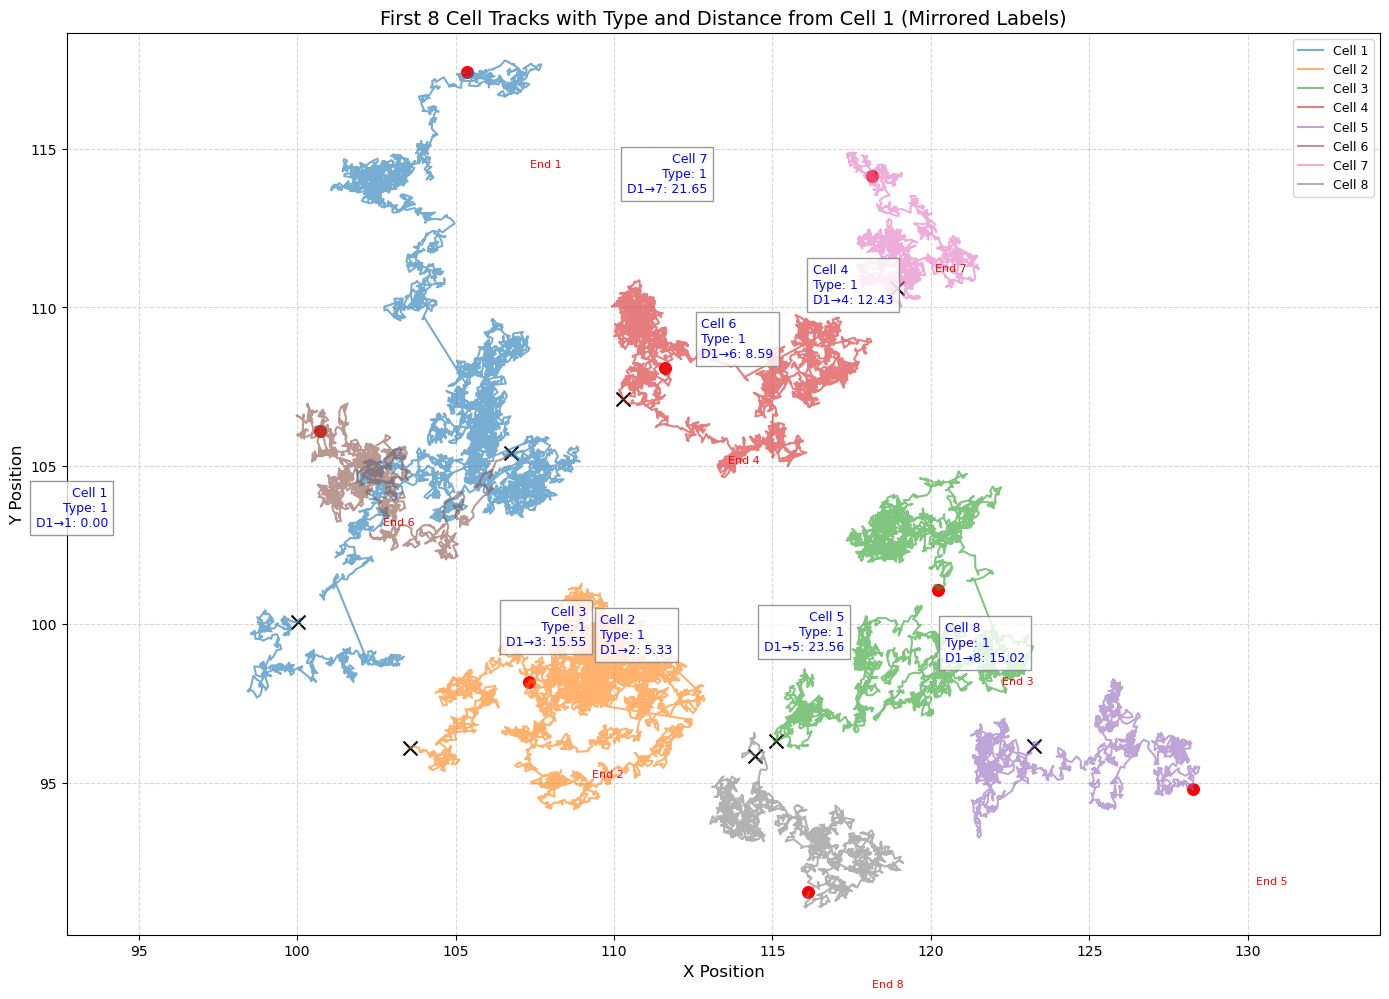

In [15]:
# Redefine necessary variables after kernel reset
# Reload data and compute required features

# Load the dataset again
file_path = "cell_typepositionS.csv"
df = pd.read_csv(file_path)

# Sort by cellid and mcs
df_sorted = df.sort_values(['cellid', 'mcs'])

# Get the first 8 unique cell IDs
first_8_cell_ids = df_sorted['cellid'].unique()[:8]

# Subset the data to include only the first 8 cells
df_first8 = df_sorted[df_sorted['cellid'].isin(first_8_cell_ids)]

# Compute start and end positions
start_positions_8 = df_first8.groupby('cellid').first().reset_index()
end_positions_8 = df_first8.groupby('cellid').last().reset_index()

# Reference position from Cell 1
ref_x, ref_y = start_positions_8.iloc[0][['x', 'y']]

# Create the plot again with mirrored label positions
plt.figure(figsize=(14, 10))

for i, cell_id in enumerate(first_8_cell_ids, start=1):
    cell_data = df_first8[df_first8['cellid'] == cell_id]
    cell_type = cell_data['cellType'].iloc[0]

    # Plot trajectory
    plt.plot(cell_data['x'], cell_data['y'], alpha=0.6, label=f'Cell {i}')

    # Start point and mirrored label
    start_x, start_y = cell_data.iloc[0][['x', 'y']]
    plt.scatter(start_x, start_y, color='black', marker='x', s=100)
    dist_from_cell1 = np.sqrt((start_x - ref_x)**2 + (start_y - ref_y)**2)

    label_x = start_x + 6 if i % 2 == 0 else start_x - 6
    ha = 'left' if i % 2 == 0 else 'right'

    plt.text(label_x, start_y + 3,
             f'Cell {i}\nType: {cell_type}\nD1→{i}: {dist_from_cell1:.2f}',
             fontsize=9, ha=ha, color='blue',
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

    # End point
    end_x, end_y = cell_data.iloc[-1][['x', 'y']]
    plt.scatter(end_x, end_y, color='red', s=70)
    plt.text(end_x + 2, end_y - 3, f'End {i}', fontsize=8, color='red')

# Final formatting
plt.xlabel('X Position', fontsize=12)
plt.ylabel('Y Position', fontsize=12)
plt.title('First 8 Cell Tracks with Type and Distance from Cell 1 (Mirrored Labels)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.axis('equal')
plt.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig("data83.png", dpi = 500, bbox_inches='tight')
plt.show()

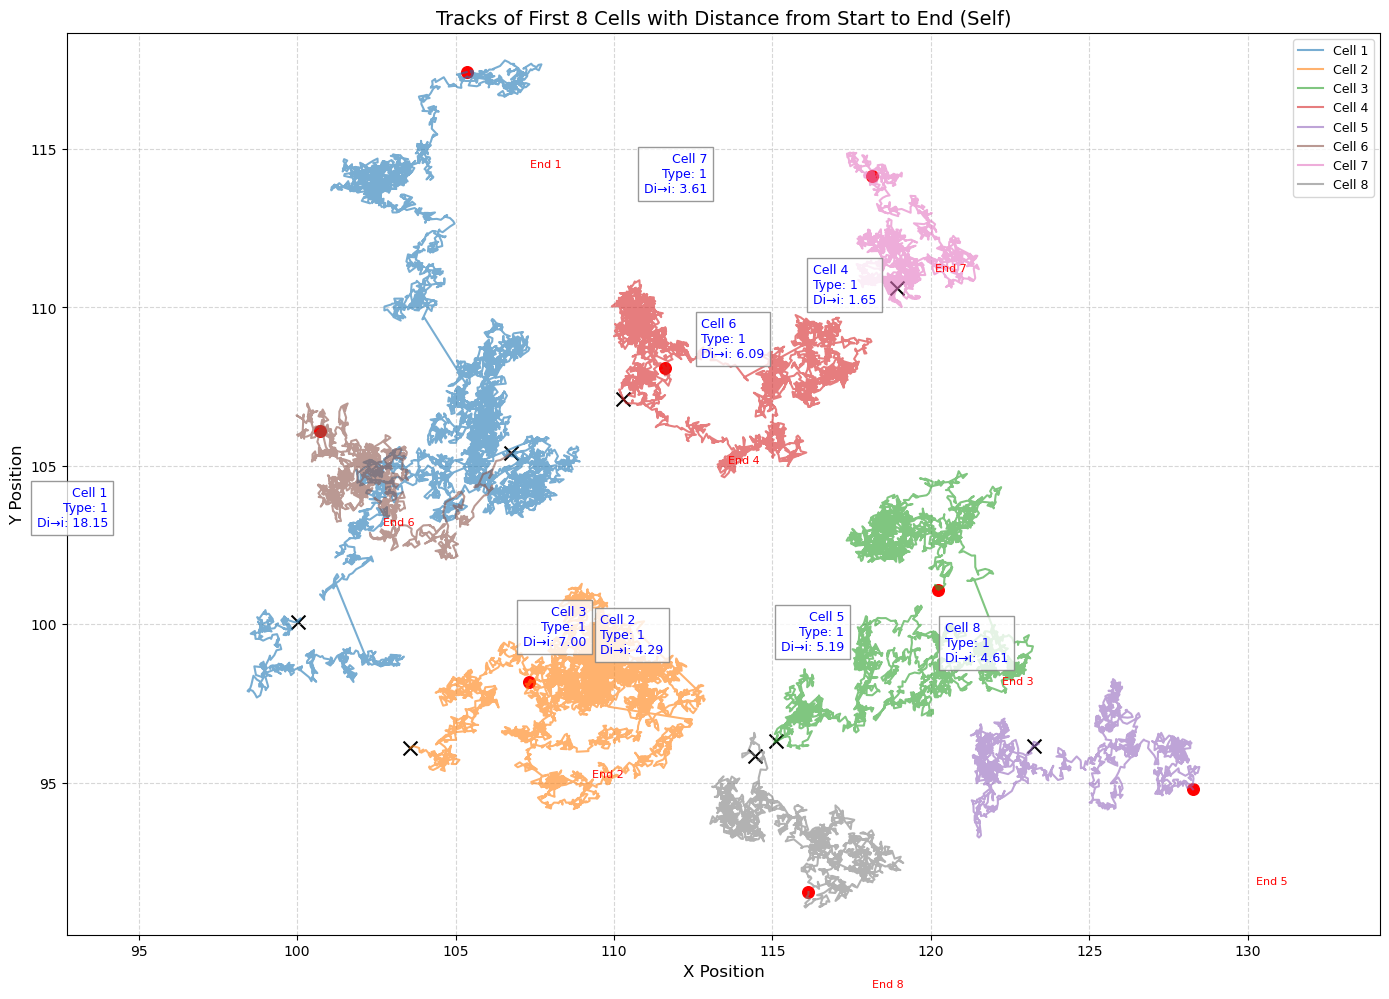

In [16]:
# Recalculate everything with distance from cell i to cell i

# Reload and sort the dataset
file_path = "cell_typepositionS.csv"
df = pd.read_csv(file_path)
df_sorted = df.sort_values(['cellid', 'mcs'])

# First 8 cell IDs and their data
first_8_cell_ids = df_sorted['cellid'].unique()[:8]
df_first8 = df_sorted[df_sorted['cellid'].isin(first_8_cell_ids)]

# Start and end positions
start_positions_8 = df_first8.groupby('cellid').first().reset_index()
end_positions_8 = df_first8.groupby('cellid').last().reset_index()

# Map of cellid -> (x, y) start positions
start_position_map = start_positions_8.set_index('cellid')[['x', 'y']]

# Begin plotting
plt.figure(figsize=(14, 10))

for i, cell_id in enumerate(first_8_cell_ids, start=1):
    cell_data = df_first8[df_first8['cellid'] == cell_id]
    cell_type = cell_data['cellType'].iloc[0]

    # Plot the cell's path
    plt.plot(cell_data['x'], cell_data['y'], alpha=0.6, label=f'Cell {i}')

    # Start and end positions
    start_x, start_y = cell_data.iloc[0][['x', 'y']]
    end_x, end_y = cell_data.iloc[-1][['x', 'y']]

    # Plot starting point
    plt.scatter(start_x, start_y, color='black', marker='x', s=100)

    # Distance from cell i to cell i (start to end)
    dist_self = np.sqrt((end_x - start_x)**2 + (end_y - start_y)**2)

    # Alternate label positions
    label_x = start_x + 6 if i % 2 == 0 else start_x - 6
    ha = 'left' if i % 2 == 0 else 'right'

    # Label near start
    plt.text(label_x, start_y + 3,
             f'Cell {i}\nType: {cell_type}\nDi→i: {dist_self:.2f}',
             fontsize=9, ha=ha, color='blue',
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

    # Plot and label end
    plt.scatter(end_x, end_y, color='red', s=70)
    plt.text(end_x + 2, end_y - 3, f'End {i}', fontsize=8, color='red')

# Final plot settings
plt.xlabel('X Position', fontsize=12)
plt.ylabel('Y Position', fontsize=12)
plt.title('Tracks of First 8 Cells with Distance from Start to End (Self)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.axis('equal')
plt.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig("data82.png", dpi = 500, bbox_inches='tight')
plt.show()

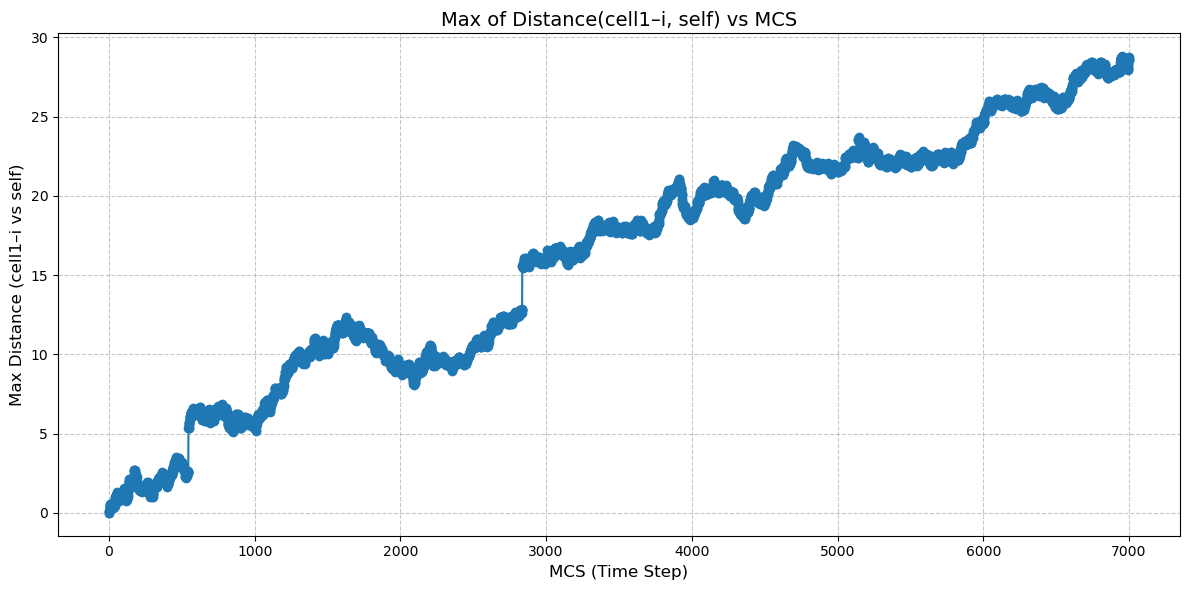

In [17]:
# Re-import required packages after code execution reset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Reload dataset
file_path = "cell_typepositionS.csv"
df = pd.read_csv(file_path)
df_sorted = df.sort_values(['cellid', 'mcs'])

# First 8 unique cell IDs and their data
first_8_cell_ids = df_sorted['cellid'].unique()[:8]
df_first8 = df_sorted[df_sorted['cellid'].isin(first_8_cell_ids)]

# Get starting positions
start_positions = df_first8.groupby('cellid').first()[['x', 'y']]
ref_x, ref_y = start_positions.loc[first_8_cell_ids[0]]

# Merge with start positions
df_merged = df_first8.merge(start_positions, on='cellid', suffixes=('', '_start'))
df_merged['ref_x'] = ref_x
df_merged['ref_y'] = ref_y

# Compute distances
df_merged['dist_cell1_i'] = np.sqrt((df_merged['x'] - df_merged['ref_x'])**2 + (df_merged['y'] - df_merged['ref_y'])**2)
df_merged['dist_self'] = np.sqrt((df_merged['x'] - df_merged['x_start'])**2 + (df_merged['y'] - df_merged['y_start'])**2)

# Max distance per row
df_merged['max_dist'] = df_merged[['dist_cell1_i', 'dist_self']].max(axis=1)

# Max distance per mcs
max_dist_by_mcs = df_merged.groupby('mcs')['max_dist'].max().reset_index()

# Plot distance vs. mcs
plt.figure(figsize=(12, 6))
plt.plot(max_dist_by_mcs['mcs'], max_dist_by_mcs['max_dist'], marker='o', linestyle='-')
plt.xlabel('MCS (Time Step)', fontsize=12)
plt.ylabel('Max Distance (cell1–i vs self)', fontsize=12)
plt.title('Max of Distance(cell1–i, self) vs MCS', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


#### Network

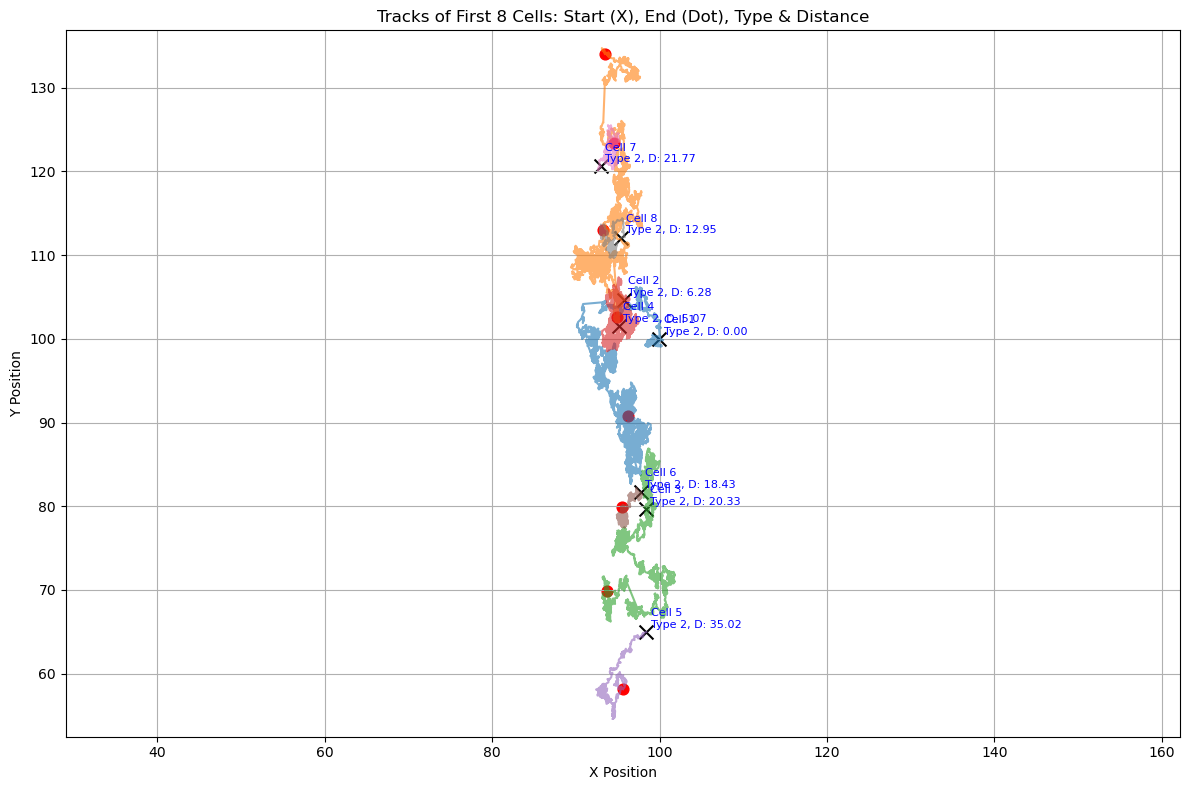

In [18]:
# Load the dataset from the specified file
file_path = "cell_typepositionN.csv"
df = pd.read_csv(file_path)

# Sort the dataframe
df_sorted = df.sort_values(['cellid', 'mcs'])

# Get the first 8 unique cell IDs
unique_cell_ids = df_sorted['cellid'].unique()[:8]

# Filter data for the first 8 cells
df_subset = df_sorted[df_sorted['cellid'].isin(unique_cell_ids)]

# Get initial and final appearances
initial_appearances = df_subset.groupby('cellid').first().reset_index()
final_appearances = df_subset.groupby('cellid').last().reset_index()

# Reference position from the first cell
ref_x = initial_appearances.iloc[0]['x']
ref_y = initial_appearances.iloc[0]['y']

# Compute Euclidean distance to the first cell's starting point
initial_appearances['distance_to_first'] = np.sqrt(
    (initial_appearances['x'] - ref_x)**2 +
    (initial_appearances['y'] - ref_y)**2
)

# Create plot
plt.figure(figsize=(12, 8))

# Plot tracks and mark start/end
for i, cell_id in enumerate(unique_cell_ids, start=1):
    cell_data = df_subset[df_subset['cellid'] == cell_id]
    cell_type = cell_data['cellType'].iloc[0]

    # Plot trajectory
    plt.plot(cell_data['x'], cell_data['y'], alpha=0.6)

    # Mark start with black X and label
    start = initial_appearances[initial_appearances['cellid'] == cell_id]
    plt.scatter(start['x'], start['y'], color='black', marker='x', s=100)
    plt.text(start['x'].values[0] + 0.5, start['y'].values[0] + 0.5,
             f'Cell {i}\nType {cell_type}, D: {start["distance_to_first"].values[0]:.2f}',
             fontsize=8, color='blue')

    # Mark end with red dot
    end = final_appearances[final_appearances['cellid'] == cell_id]
    plt.scatter(end['x'], end['y'], color='red', s=60)

# Final plot formatting
plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.title('Tracks of First 8 Cells: Start (X), End (Dot), Type & Distance')
plt.grid(True)
plt.axis('equal')
plt.tight_layout()
plt.show()

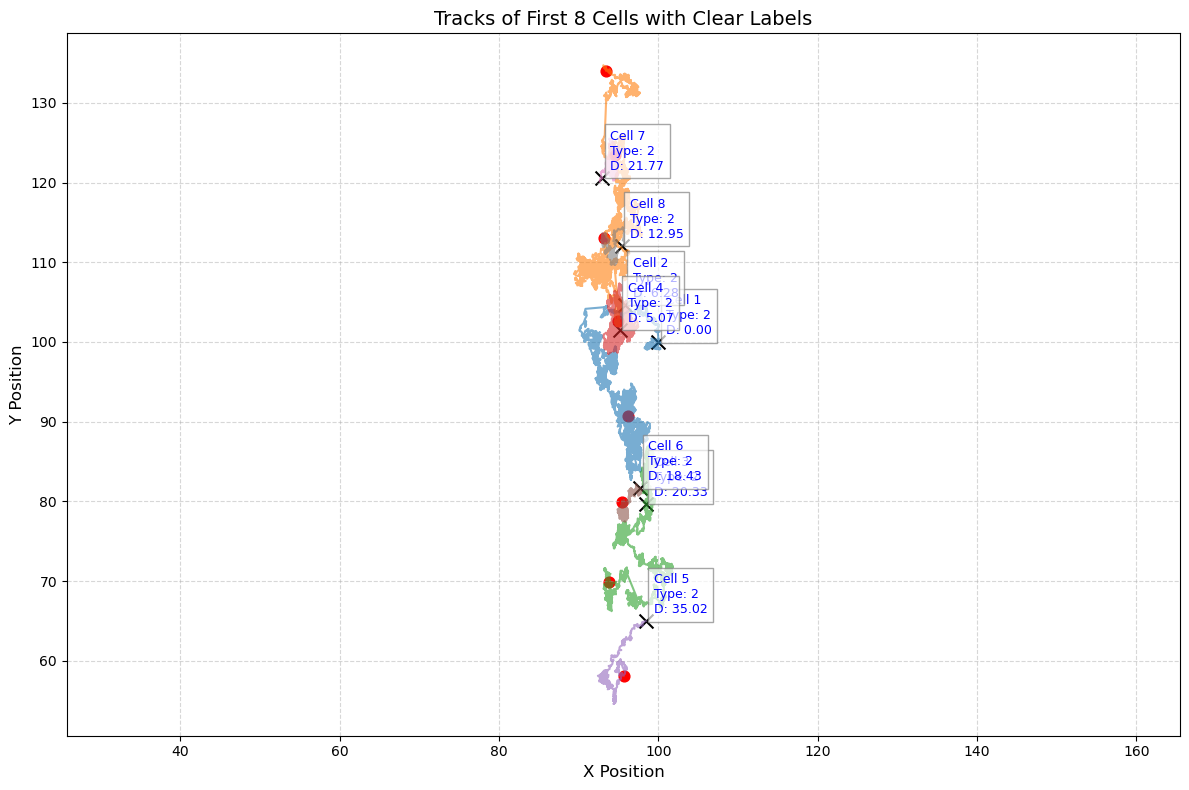

In [19]:
# Create plot again with improved label formatting and cell type display
plt.figure(figsize=(12, 8))

# Plot tracks and mark start/end
for i, cell_id in enumerate(unique_cell_ids, start=1):
    cell_data = df_subset[df_subset['cellid'] == cell_id]
    cell_type = cell_data['cellType'].iloc[0]

    # Plot trajectory
    plt.plot(cell_data['x'], cell_data['y'], alpha=0.6)

    # Mark start with black X
    start = initial_appearances[initial_appearances['cellid'] == cell_id]
    start_x, start_y = start['x'].values[0], start['y'].values[0]
    distance = start['distance_to_first'].values[0]

    plt.scatter(start_x, start_y, color='black', marker='x', s=100)

    # Label: Cell number, type, and distance
    plt.text(start_x + 1, start_y + 1,
             f'Cell {i}\nType: {cell_type}\nD: {distance:.2f}',
             fontsize=9, color='blue', bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray'))

    # Mark end with red dot
    end = final_appearances[final_appearances['cellid'] == cell_id]
    plt.scatter(end['x'], end['y'], color='red', s=60)

# Final plot formatting
plt.xlabel('X Position', fontsize=12)
plt.ylabel('Y Position', fontsize=12)
plt.title('Tracks of First 8 Cells with Clear Labels', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.axis('equal')
plt.tight_layout()
plt.show()


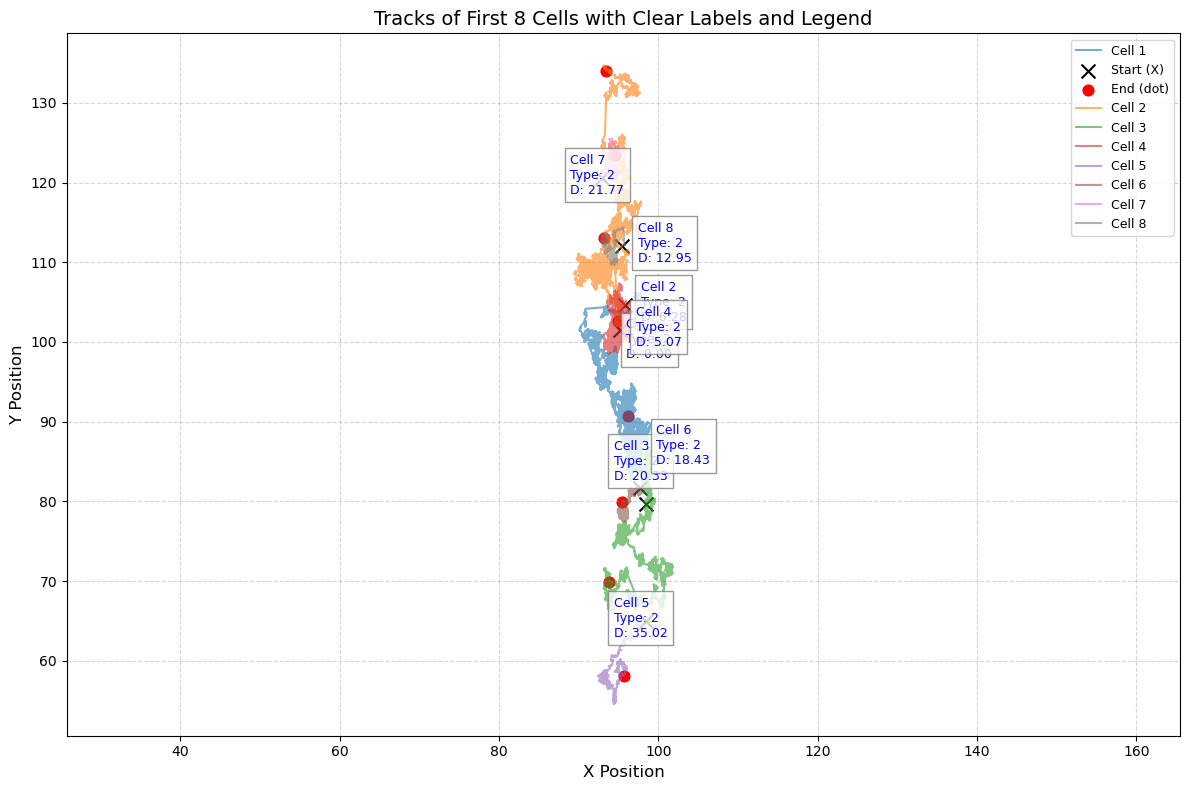

In [20]:
# Create plot again with non-overlapping labels and proper legend
plt.figure(figsize=(12, 8))

# To track legends (avoid duplicates)
plotted_labels = set()

# Plot tracks and mark start/end
for i, cell_id in enumerate(unique_cell_ids, start=1):
    cell_data = df_subset[df_subset['cellid'] == cell_id]
    cell_type = cell_data['cellType'].iloc[0]

    # Plot trajectory
    label = f'Cell {i}' if f'Cell {i}' not in plotted_labels else None
    plt.plot(cell_data['x'], cell_data['y'], alpha=0.6, label=label)
    plotted_labels.add(f'Cell {i}')

    # Mark start with black X
    start = initial_appearances[initial_appearances['cellid'] == cell_id]
    start_x, start_y = start['x'].values[0], start['y'].values[0]
    distance = start['distance_to_first'].values[0]

    plt.scatter(start_x, start_y, color='black', marker='x', s=100, label='Start (X)' if i == 1 else "")

    # Adjust label positions to avoid overlapping
    label_offset_x = 2 if i % 2 == 0 else -4
    label_offset_y = 3 if i % 3 == 0 else -2

    # Label: Cell number, type, and distance
    plt.text(start_x + label_offset_x, start_y + label_offset_y,
             f'Cell {i}\nType: {cell_type}\nD: {distance:.2f}',
             fontsize=9, color='blue', bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

    # Mark end with red dot
    end = final_appearances[final_appearances['cellid'] == cell_id]
    plt.scatter(end['x'], end['y'], color='red', s=60, label='End (dot)' if i == 1 else "")

# Final plot formatting
plt.xlabel('X Position', fontsize=12)
plt.ylabel('Y Position', fontsize=12)
plt.title('Tracks of First 8 Cells with Clear Labels and Legend', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.axis('equal')
plt.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

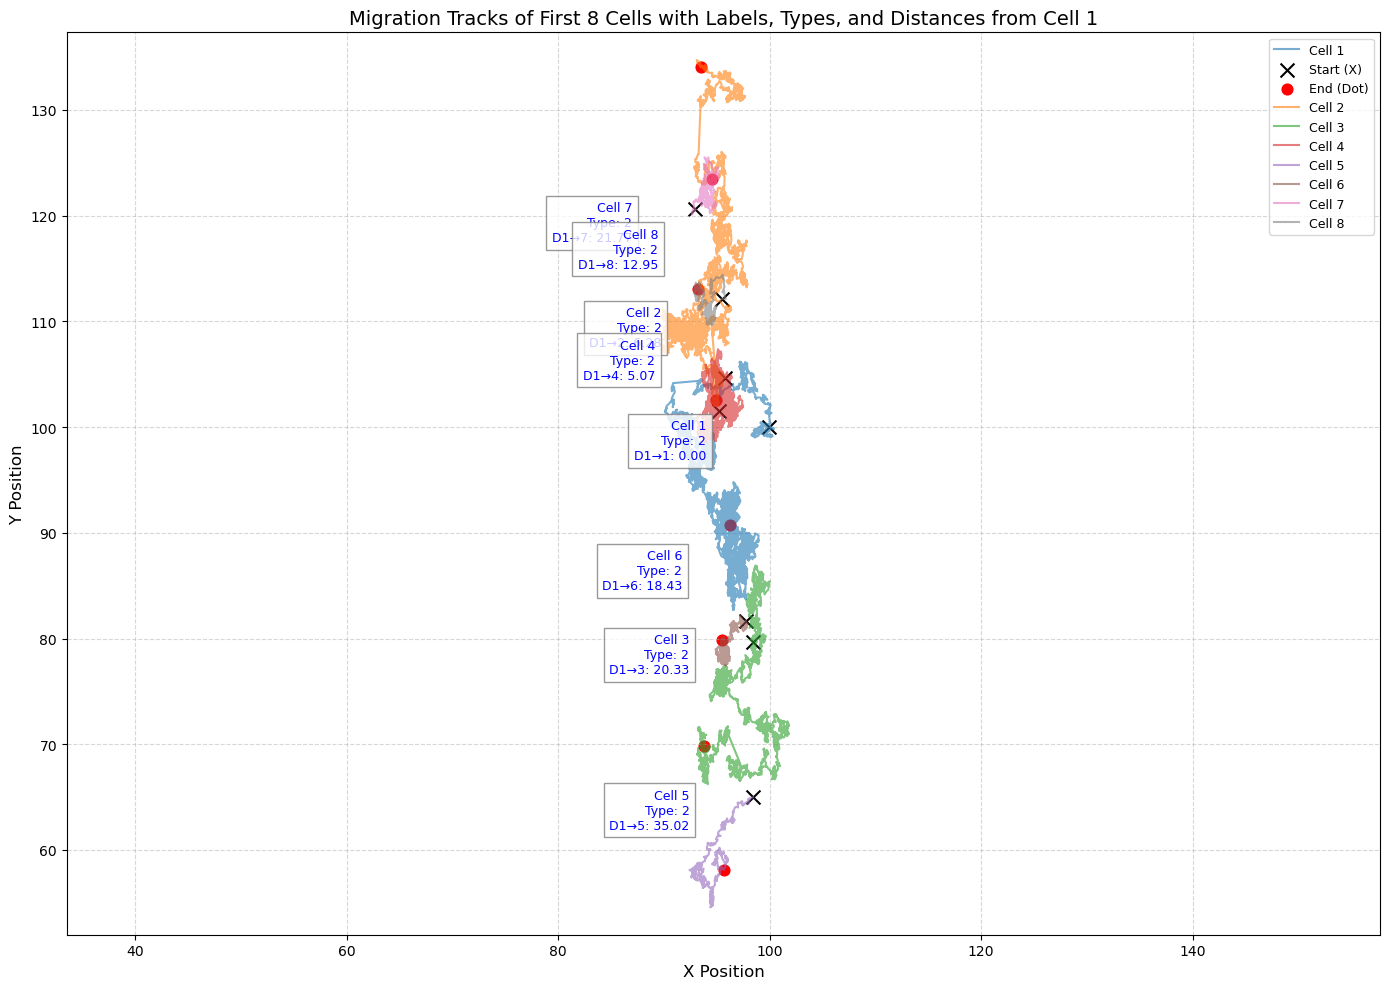

In [21]:
# Load the dataset from the latest upload
file_path = "cell_typepositionN.csv"
df = pd.read_csv(file_path)

# Sort by cell ID and time step (mcs)
df_sorted = df.sort_values(['cellid', 'mcs'])

# Select the first 8 unique cell IDs
unique_cell_ids = df_sorted['cellid'].unique()[:8]

# Subset the dataframe to include only the first 8 cells
df_subset = df_sorted[df_sorted['cellid'].isin(unique_cell_ids)]

# Compute initial and final positions
initial_positions = df_subset.groupby('cellid').first().reset_index()
final_positions = df_subset.groupby('cellid').last().reset_index()

# Get pairwise distances between initial positions
from itertools import product
init_coords = initial_positions.set_index('cellid')[['x', 'y']]
distance_matrix = pd.DataFrame(index=unique_cell_ids, columns=unique_cell_ids, dtype=float)

for i, j in product(unique_cell_ids, repeat=2):
    x_i, y_i = init_coords.loc[i]
    x_j, y_j = init_coords.loc[j]
    distance_matrix.loc[i, j] = np.sqrt((x_i - x_j)**2 + (y_i - y_j)**2)

# Plot cell migration tracks and annotations
plt.figure(figsize=(14, 10))

for idx, cell_id in enumerate(unique_cell_ids, start=1):
    cell_data = df_subset[df_subset['cellid'] == cell_id]
    cell_type = cell_data['cellType'].iloc[0]

    # Plot trajectory
    plt.plot(cell_data['x'], cell_data['y'], alpha=0.6, label=f'Cell {idx}')

    # Start position
    start_x, start_y = cell_data.iloc[0][['x', 'y']]
    plt.scatter(start_x, start_y, color='black', marker='x', s=100, label='Start (X)' if idx == 1 else "")

    # End position
    end_x, end_y = cell_data.iloc[-1][['x', 'y']]
    plt.scatter(end_x, end_y, color='red', s=60, label='End (Dot)' if idx == 1 else "")

    # Distance from Cell 1 to Cell i
    dist_from_cell1 = distance_matrix.loc[unique_cell_ids[0], cell_id]

    # Annotate label on the left side
    label_offset_x = -6
    label_offset_y = 3 if idx % 2 == 0 else -3
    plt.text(start_x + label_offset_x, start_y + label_offset_y,
             f'Cell {idx}\nType: {cell_type}\nD1→{idx}: {dist_from_cell1:.2f}',
             fontsize=9, color='blue',
             ha='right',
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

# Plot formatting
plt.xlabel('X Position', fontsize=12)
plt.ylabel('Y Position', fontsize=12)
plt.title('Migration Tracks of First 8 Cells with Labels, Types, and Distances from Cell 1', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.axis('equal')
plt.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

Features Implemented:
Tracks for Cells 1 to 8: Each line traces the full migration path over time.

Start Point (Black X) and End Point (Red Dot) for each cell.

Annotations:

Cell # (1–8)

Cell Type

D1→i: Distance from Cell 1 to Cell i (computed from starting positions).

Labels are placed to the left side of each start point to enhance readability.

In [22]:
# Load the latest uploaded dataset
import pandas as pd
import numpy as np

file_path = "cell_typepositionN.csv"
df = pd.read_csv(file_path)

# Sort the dataframe by cellid and time step
df_sorted = df.sort_values(['cellid', 'mcs']).reset_index(drop=True)

# Get the initial positions for each cellid
initial_positions = df_sorted.groupby('cellid').first().reset_index()
initial_positions = initial_positions.set_index('cellid')[['x', 'y']]

# Get the reference position (cellid with smallest ID)
ref_cellid = initial_positions.index.min()
ref_x, ref_y = initial_positions.loc[ref_cellid]

# Merge initial positions (self) to each row in df
df_with_self = df_sorted.merge(initial_positions, on='cellid', suffixes=('', '_self'))

# Add reference position to all rows
df_with_self['ref_x'] = ref_x
df_with_self['ref_y'] = ref_y

# Compute distances
df_with_self['dist_to_cell1'] = np.sqrt((df_with_self['x'] - df_with_self['ref_x'])**2 + 
                                        (df_with_self['y'] - df_with_self['ref_y'])**2)
df_with_self['dist_to_self'] = np.sqrt((df_with_self['x'] - df_with_self['x_self'])**2 + 
                                       (df_with_self['y'] - df_with_self['y_self'])**2)

# Max distance to cell1 per mcs
df_with_self['max_dist_to_cell1_mcs'] = df_with_self.groupby('mcs')['dist_to_cell1'].transform('max')

# Max distance among both metrics per mcs
df_with_self['max_dist_overall_mcs'] = df_with_self[['dist_to_cell1', 'dist_to_self']].max(axis=1)
df_with_self['max_dist_overall_mcs'] = df_with_self.groupby('mcs')['max_dist_overall_mcs'].transform('max')

# Compute start and end positions for each cell
start_positions = df_sorted.groupby('cellid').first().reset_index()
end_positions = df_sorted.groupby('cellid').last().reset_index()

# Save updated data for plotting
df_final = df_with_self.copy()

## Display the first few rows with new features
#import ace_tools as tools; tools.display_dataframe_to_user(name="Cell Distances and Metrics", dataframe=df_final)

In [23]:
# Re-import necessary packages after kernel reset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Reload the uploaded dataset
file_path = "cell_typepositionN.csv"
df = pd.read_csv(file_path)

# Sort the dataframe
df_sorted = df.sort_values(['cellid', 'mcs']).reset_index(drop=True)

# Get the initial positions for each cellid
initial_positions = df_sorted.groupby('cellid').first().reset_index()
initial_positions = initial_positions.set_index('cellid')[['x', 'y']]

# Get reference position (smallest cellid)
ref_cellid = initial_positions.index.min()
ref_x, ref_y = initial_positions.loc[ref_cellid]

# Merge initial positions (self) with the full dataframe
df_with_self = df_sorted.merge(initial_positions, on='cellid', suffixes=('', '_self'))

# Add reference position
df_with_self['ref_x'] = ref_x
df_with_self['ref_y'] = ref_y

# Compute distances
df_with_self['dist_to_cell1'] = np.sqrt((df_with_self['x'] - df_with_self['ref_x'])**2 +
                                        (df_with_self['y'] - df_with_self['ref_y'])**2)

df_with_self['dist_to_self'] = np.sqrt((df_with_self['x'] - df_with_self['x_self'])**2 +
                                       (df_with_self['y'] - df_with_self['y_self'])**2)

# Max distance to cell1 per mcs
df_with_self['max_dist_to_cell1_mcs'] = df_with_self.groupby('mcs')['dist_to_cell1'].transform('max')

# Max distance between dist_to_cell1 and dist_to_self per mcs
df_with_self['max_dist_overall_mcs'] = df_with_self[['dist_to_cell1', 'dist_to_self']].max(axis=1)
df_with_self['max_dist_overall_mcs'] = df_with_self.groupby('mcs')['max_dist_overall_mcs'].transform('max')

# Compute start and end positions for each cell
start_positions = df_sorted.groupby('cellid').first().reset_index()
end_positions = df_sorted.groupby('cellid').last().reset_index()

# Display updated data
#import ace_tools as tools; 
#tools.display_dataframe_to_user(name="Cell Distances and Metrics", dataframe=df_with_self)


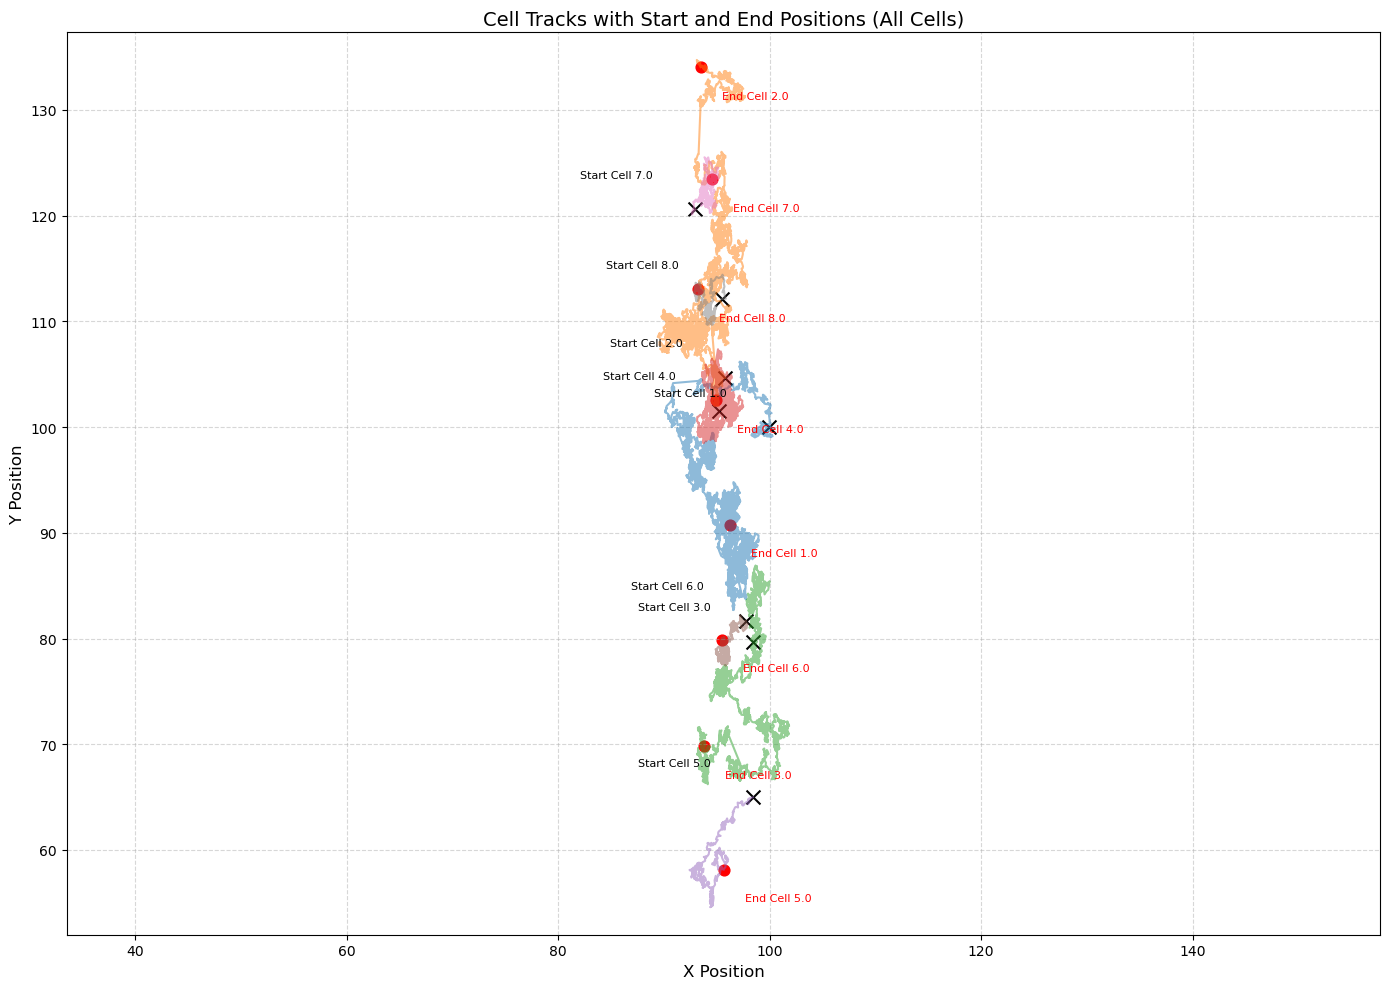

In [24]:
# Create a plot of cell tracks with start (X), end (dot), and cellid annotations

plt.figure(figsize=(14, 10))

# Plot all tracks
for cell_id in df_sorted['cellid'].unique():
    cell_data = df_sorted[df_sorted['cellid'] == cell_id]
    plt.plot(cell_data['x'], cell_data['y'], alpha=0.5, label=f'Cell {cell_id}')

# Mark start positions with black X and end with red dot
for _, row in start_positions.iterrows():
    plt.scatter(row['x'], row['y'], color='black', marker='x', s=100)
    plt.text(row['x'] - 4, row['y'] + 3, f'Start Cell {row["cellid"]}', fontsize=8, ha='right', color='black')

for _, row in end_positions.iterrows():
    plt.scatter(row['x'], row['y'], color='red', s=60)
    plt.text(row['x'] + 2, row['y'] - 3, f'End Cell {row["cellid"]}', fontsize=8, ha='left', color='red')

# Final formatting
plt.xlabel('X Position', fontsize=12)
plt.ylabel('Y Position', fontsize=12)
plt.title('Cell Tracks with Start and End Positions (All Cells)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.axis('equal')
plt.tight_layout()
plt.show()

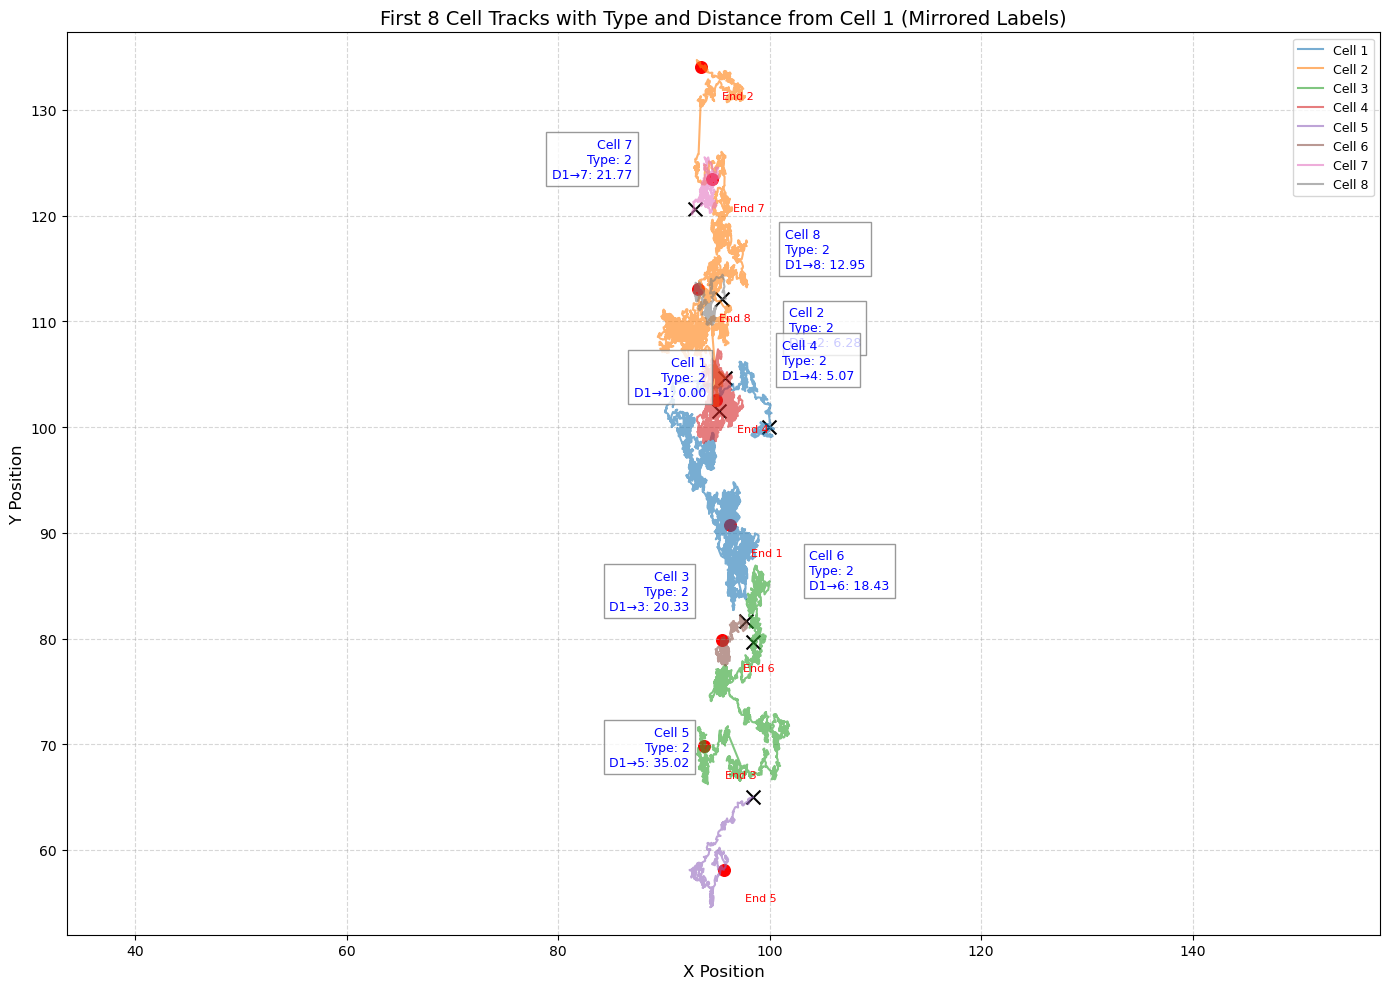

In [25]:
# Redefine necessary variables after kernel reset
# Reload data and compute required features

# Load the dataset again
file_path = "cell_typepositionN.csv"
df = pd.read_csv(file_path)

# Sort by cellid and mcs
df_sorted = df.sort_values(['cellid', 'mcs'])

# Get the first 8 unique cell IDs
first_8_cell_ids = df_sorted['cellid'].unique()[:8]

# Subset the data to include only the first 8 cells
df_first8 = df_sorted[df_sorted['cellid'].isin(first_8_cell_ids)]

# Compute start and end positions
start_positions_8 = df_first8.groupby('cellid').first().reset_index()
end_positions_8 = df_first8.groupby('cellid').last().reset_index()

# Reference position from Cell 1
ref_x, ref_y = start_positions_8.iloc[0][['x', 'y']]

# Create the plot again with mirrored label positions
plt.figure(figsize=(14, 10))

for i, cell_id in enumerate(first_8_cell_ids, start=1):
    cell_data = df_first8[df_first8['cellid'] == cell_id]
    cell_type = cell_data['cellType'].iloc[0]

    # Plot trajectory
    plt.plot(cell_data['x'], cell_data['y'], alpha=0.6, label=f'Cell {i}')

    # Start point and mirrored label
    start_x, start_y = cell_data.iloc[0][['x', 'y']]
    plt.scatter(start_x, start_y, color='black', marker='x', s=100)
    dist_from_cell1 = np.sqrt((start_x - ref_x)**2 + (start_y - ref_y)**2)

    label_x = start_x + 6 if i % 2 == 0 else start_x - 6
    ha = 'left' if i % 2 == 0 else 'right'

    plt.text(label_x, start_y + 3,
             f'Cell {i}\nType: {cell_type}\nD1→{i}: {dist_from_cell1:.2f}',
             fontsize=9, ha=ha, color='blue',
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

    # End point
    end_x, end_y = cell_data.iloc[-1][['x', 'y']]
    plt.scatter(end_x, end_y, color='red', s=70)
    plt.text(end_x + 2, end_y - 3, f'End {i}', fontsize=8, color='red')

# Final formatting
plt.xlabel('X Position', fontsize=12)
plt.ylabel('Y Position', fontsize=12)
plt.title('First 8 Cell Tracks with Type and Distance from Cell 1 (Mirrored Labels)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.axis('equal')
plt.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig("data81.png", dpi = 500, bbox_inches='tight')
plt.show()

##### cell i ---> cell i

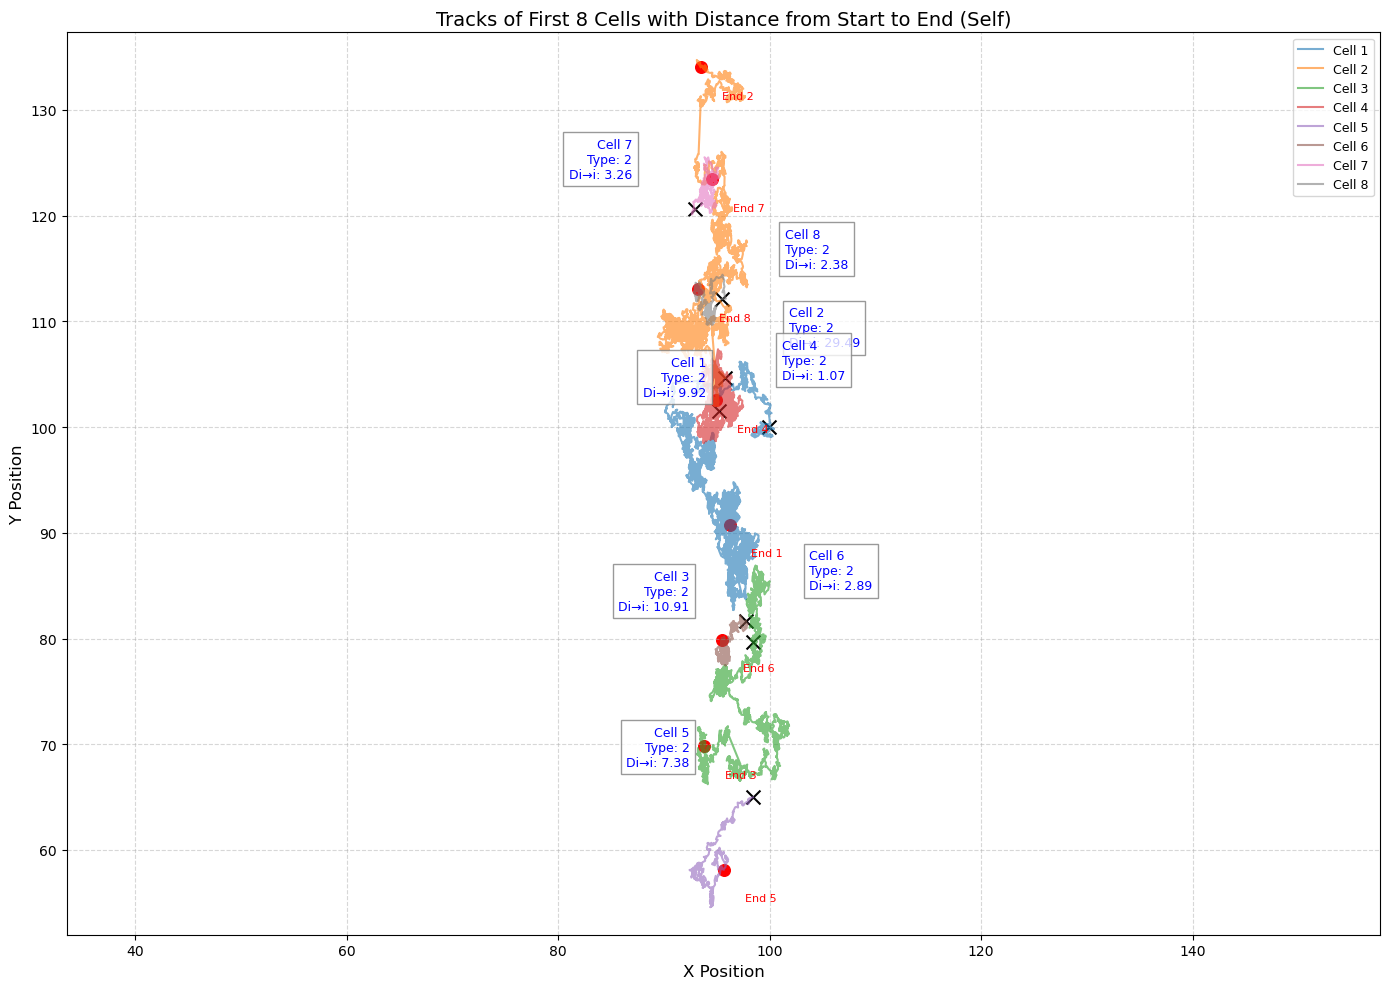

In [26]:
# Recalculate everything with distance from cell i to cell i

# Reload and sort the dataset
file_path = "cell_typepositionN.csv"
df = pd.read_csv(file_path)
df_sorted = df.sort_values(['cellid', 'mcs'])

# First 8 cell IDs and their data
first_8_cell_ids = df_sorted['cellid'].unique()[:8]
df_first8 = df_sorted[df_sorted['cellid'].isin(first_8_cell_ids)]

# Start and end positions
start_positions_8 = df_first8.groupby('cellid').first().reset_index()
end_positions_8 = df_first8.groupby('cellid').last().reset_index()

# Map of cellid -> (x, y) start positions
start_position_map = start_positions_8.set_index('cellid')[['x', 'y']]

# Begin plotting
plt.figure(figsize=(14, 10))

for i, cell_id in enumerate(first_8_cell_ids, start=1):
    cell_data = df_first8[df_first8['cellid'] == cell_id]
    cell_type = cell_data['cellType'].iloc[0]

    # Plot the cell's path
    plt.plot(cell_data['x'], cell_data['y'], alpha=0.6, label=f'Cell {i}')

    # Start and end positions
    start_x, start_y = cell_data.iloc[0][['x', 'y']]
    end_x, end_y = cell_data.iloc[-1][['x', 'y']]

    # Plot starting point
    plt.scatter(start_x, start_y, color='black', marker='x', s=100)

    # Distance from cell i to cell i (start to end)
    dist_self = np.sqrt((end_x - start_x)**2 + (end_y - start_y)**2)

    # Alternate label positions
    label_x = start_x + 6 if i % 2 == 0 else start_x - 6
    ha = 'left' if i % 2 == 0 else 'right'

    # Label near start
    plt.text(label_x, start_y + 3,
             f'Cell {i}\nType: {cell_type}\nDi→i: {dist_self:.2f}',
             fontsize=9, ha=ha, color='blue',
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

    # Plot and label end
    plt.scatter(end_x, end_y, color='red', s=70)
    plt.text(end_x + 2, end_y - 3, f'End {i}', fontsize=8, color='red')

# Final plot settings
plt.xlabel('X Position', fontsize=12)
plt.ylabel('Y Position', fontsize=12)
plt.title('Tracks of First 8 Cells with Distance from Start to End (Self)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.axis('equal')
plt.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig("data80.png", dpi = 500, bbox_inches='tight')
plt.show()

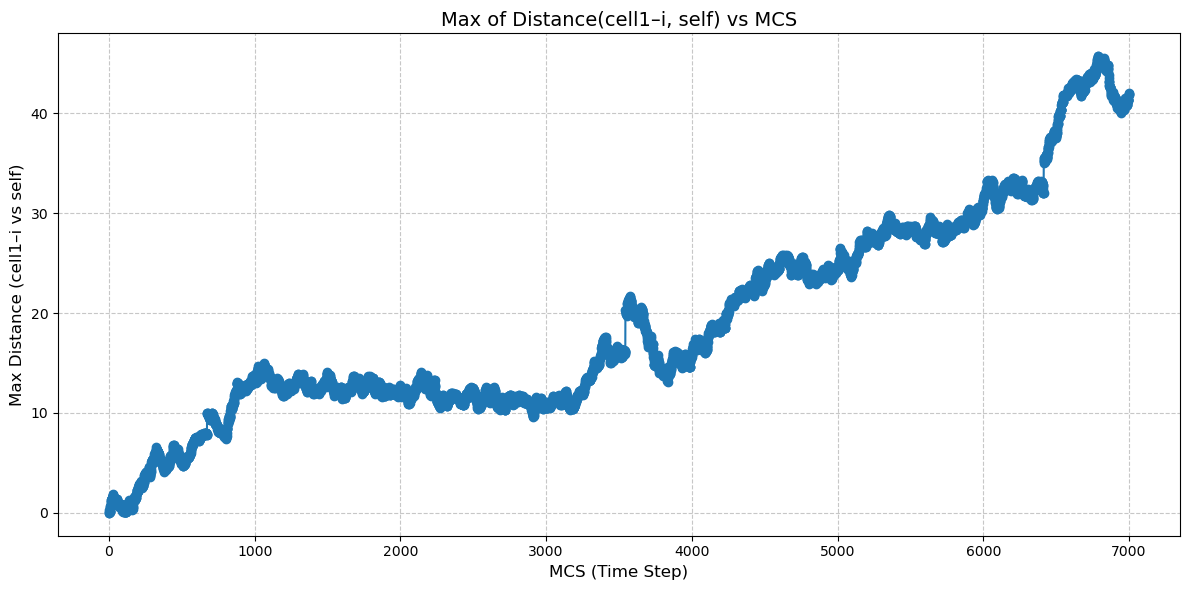

In [27]:
# Re-import required packages after code execution reset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Reload dataset
file_path = "cell_typepositionN.csv"
df = pd.read_csv(file_path)
df_sorted = df.sort_values(['cellid', 'mcs'])

# First 8 unique cell IDs and their data
first_8_cell_ids = df_sorted['cellid'].unique()[:8]
df_first8 = df_sorted[df_sorted['cellid'].isin(first_8_cell_ids)]

# Get starting positions
start_positions = df_first8.groupby('cellid').first()[['x', 'y']]
ref_x, ref_y = start_positions.loc[first_8_cell_ids[0]]

# Merge with start positions
df_merged = df_first8.merge(start_positions, on='cellid', suffixes=('', '_start'))
df_merged['ref_x'] = ref_x
df_merged['ref_y'] = ref_y

# Compute distances
df_merged['dist_cell1_i'] = np.sqrt((df_merged['x'] - df_merged['ref_x'])**2 + (df_merged['y'] - df_merged['ref_y'])**2)
df_merged['dist_self'] = np.sqrt((df_merged['x'] - df_merged['x_start'])**2 + (df_merged['y'] - df_merged['y_start'])**2)

# Max distance per row
df_merged['max_dist'] = df_merged[['dist_cell1_i', 'dist_self']].max(axis=1)

# Max distance per mcs
max_dist_by_mcs = df_merged.groupby('mcs')['max_dist'].max().reset_index()

# Plot distance vs. mcs
plt.figure(figsize=(12, 6))
plt.plot(max_dist_by_mcs['mcs'], max_dist_by_mcs['max_dist'], marker='o', linestyle='-')
plt.xlabel('MCS (Time Step)', fontsize=12)
plt.ylabel('Max Distance (cell1–i vs self)', fontsize=12)
plt.title('Max of Distance(cell1–i, self) vs MCS', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### Combinded Plot

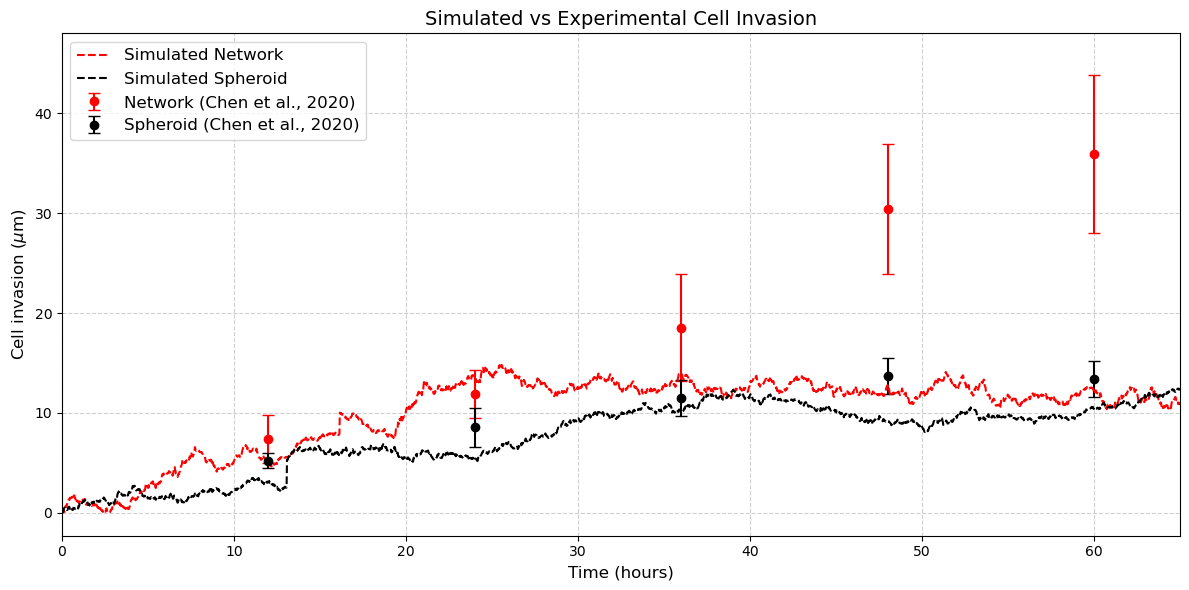

In [28]:
# Step-by-step: Full computation and plotting from scratch

# Re-import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
network_df = pd.read_csv("cell_typepositionN.csv")
spheroid_df = pd.read_csv("cell_typepositionS.csv")

# Sort data
network_df = network_df.sort_values(['cellid', 'mcs'])
spheroid_df = spheroid_df.sort_values(['cellid', 'mcs'])

# Helper function to compute max(migration from cell1 to i, i to i) per mcs
def compute_max_migration(df):
    first_8_ids = df['cellid'].unique()[:8]
    df_subset = df[df['cellid'].isin(first_8_ids)]
    start_positions = df_subset.groupby('cellid').first()[['x', 'y']]
    ref_x, ref_y = start_positions.loc[first_8_ids[0]]
    
    # Merge starting positions
    df_merged = df_subset.merge(start_positions, on='cellid', suffixes=('', '_start'))
    df_merged['ref_x'] = ref_x
    df_merged['ref_y'] = ref_y

    # Compute distances
    df_merged['dist_cell1_i'] = np.sqrt((df_merged['x'] - df_merged['ref_x'])**2 + (df_merged['y'] - df_merged['ref_y'])**2)
    df_merged['dist_self'] = np.sqrt((df_merged['x'] - df_merged['x_start'])**2 + (df_merged['y'] - df_merged['y_start'])**2)

    # Max per cell per time point
    df_merged['max_dist'] = df_merged[['dist_cell1_i', 'dist_self']].max(axis=1)

    # Max of maxes per mcs
    max_by_mcs = df_merged.groupby('mcs')['max_dist'].max().reset_index()
    max_by_mcs['time_hr'] = max_by_mcs['mcs'] * 0.024  # 1000 MCS = 24 hrs
    return max_by_mcs

# Compute migration data
network_max = compute_max_migration(network_df)
spheroid_max = compute_max_migration(spheroid_df)

# Experimental data (Chen et al., 2020)
network_days = [12, 24, 36, 48, 60]
network_conc = [7.41, 11.88, 18.53, 30.42, 35.91]
network_error = [2.43, 2.43, 5.37, 6.52, 7.92]

spheroid_days = [12, 24, 36, 48, 60]
spheroid_conc = [5.24, 8.56, 11.50, 13.67, 13.42]
spheroid_error = [0.77, 1.92, 1.79, 1.79, 1.79]

# Plotting
plt.figure(figsize=(12, 6))

# Experimental
plt.errorbar(network_days, network_conc, yerr=network_error, color='red', fmt='o', capsize=4, label='Network (Chen et al., 2020)')
plt.errorbar(spheroid_days, spheroid_conc, yerr=spheroid_error, color='black', fmt='o', capsize=4, label='Spheroid (Chen et al., 2020)')

# Simulation
plt.plot(network_max['time_hr'], network_max['max_dist'], label='Simulated Network', color='red', linestyle='--')
plt.plot(spheroid_max['time_hr'], spheroid_max['max_dist'], label='Simulated Spheroid', color='black', linestyle='--')

# Formatting
plt.xlabel('Time (hours)', fontsize=12)
plt.ylabel('Cell invasion ($\mu$m)', fontsize=12)
plt.title('Simulated vs Experimental Cell Invasion', fontsize=14)
plt.xlim(0, 65)
plt.legend(loc='best', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("cell_structure_experiment_data.png", dpi=500, bbox_inches='tight')
plt.show()

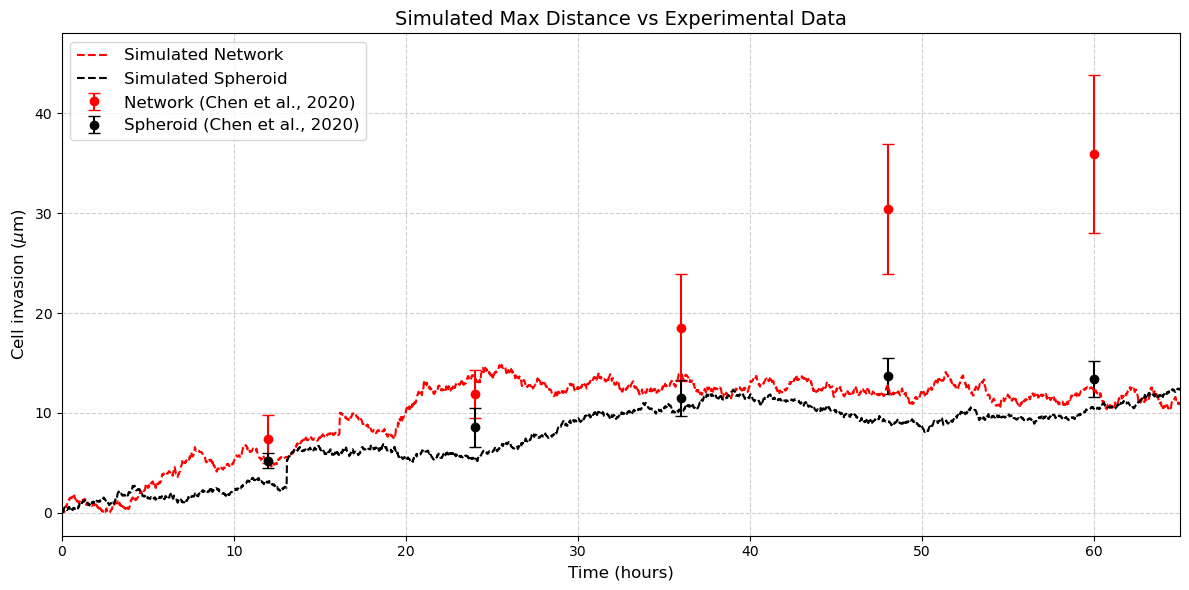

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

# Experimental Data
network_days = [12, 24, 36, 48, 60]
network_conc = [7.41, 11.88, 18.53, 30.42, 35.91]
network_error = [2.43, 2.43, 5.37, 6.52, 7.92]

spheroid_days = [12, 24, 36, 48, 60]
spheroid_conc = [5.24, 8.56, 11.50, 13.67, 13.42]
spheroid_error = [0.77, 1.92, 1.79, 1.79, 1.79]

# Function to compute max distances
def compute_max_distances(file_paths):
    dfs = []
    for file_path in file_paths:
        df = pd.read_csv(file_path)
        df_sorted = df.sort_values(['mcs'])
        start_x, start_y = df_sorted.iloc[0][['x', 'y']]
        ref_x, ref_y = start_x, start_y
        df_sorted['dist_self'] = np.sqrt((df_sorted['x'] - start_x)**2 + (df_sorted['y'] - start_y)**2)
        df_sorted['ref_x'] = ref_x
        df_sorted['ref_y'] = ref_y
        dfs.append(df_sorted)
    combined_df = pd.concat(dfs, ignore_index=True)
    cell1_data = pd.read_csv(file_paths[0])
    cell1_start_x, cell1_start_y = cell1_data.iloc[0][['x', 'y']]
    combined_df['dist_to_cell1'] = np.sqrt((combined_df['x'] - cell1_start_x)**2 + (combined_df['y'] - cell1_start_y)**2)
    combined_df['max_dist'] = combined_df[['dist_self', 'dist_to_cell1']].max(axis=1)
    max_dist_by_mcs = combined_df.groupby('mcs')['max_dist'].max().reset_index()
    return max_dist_by_mcs

# Identify files
all_files = sorted(glob.glob("cell_typeposition*.csv"))
spheroid_files = [f for f in all_files if "S" in f or "spheroid" in f.lower()]
network_files = [f for f in all_files if "N" in f or "network" in f.lower()]
if len(spheroid_files) == 0 and len(network_files) == 0:
    network_files = [f for i, f in enumerate(all_files) if i % 2 == 0]
    spheroid_files = [f for i, f in enumerate(all_files) if i % 2 == 1]

# Compute max distances
spheroid_distances = compute_max_distances(spheroid_files)
network_distances = compute_max_distances(network_files)

# Convert MCS to hours
spheroid_distances['time_hr'] = spheroid_distances['mcs'] * 0.024
network_distances['time_hr'] = network_distances['mcs'] * 0.024

# Plot
plt.figure(figsize=(12, 6))

# Experimental
plt.errorbar(network_days, network_conc, yerr=network_error, color='red', fmt='o', capsize=4, label='Network (Chen et al., 2020)')
plt.errorbar(spheroid_days, spheroid_conc, yerr=spheroid_error, color='black', fmt='o', capsize=4, label='Spheroid (Chen et al., 2020)')

# Simulated
plt.plot(network_distances['time_hr'], network_distances['max_dist'], color='red', linestyle='--', label='Simulated Network')
plt.plot(spheroid_distances['time_hr'], spheroid_distances['max_dist'], color='black', linestyle='--', label='Simulated Spheroid')

# Formatting
plt.xlabel('Time (hours)', fontsize=12)
plt.ylabel('Cell invasion ($\mu$m)', fontsize=12)
plt.title('Simulated Max Distance vs Experimental Data', fontsize=14)
plt.xlim(0, 65)
plt.legend(loc='best', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

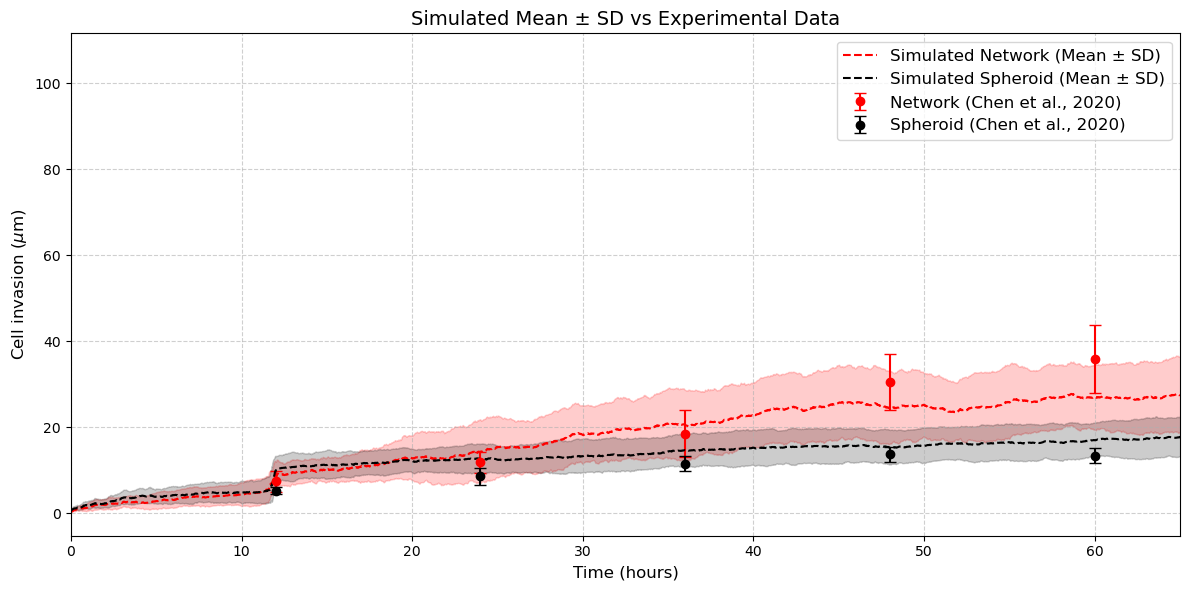

In [30]:
# Define folders for real replicate data
spheroid_folder = "spheroid_1"
network_folder = "network_1"

# Locate CSV files
spheroid_files = sorted(glob.glob(os.path.join(spheroid_folder, "cell_typeposition*.csv")))
network_files = sorted(glob.glob(os.path.join(network_folder, "cell_typeposition*.csv")))

# Enhanced version of compute_max_distances that returns per replicate
def get_max_distance_per_mcs(file_paths):
    replicate_data = []
    for path in file_paths:
        df = pd.read_csv(path)
        df_sorted = df.sort_values(['mcs'])
        x0, y0 = df_sorted.iloc[0][['x', 'y']]
        df_sorted['dist_self'] = np.sqrt((df_sorted['x'] - x0)**2 + (df_sorted['y'] - y0)**2)

        # Distance to first replicate's first cell
        ref_df = pd.read_csv(file_paths[0])
        ref_x, ref_y = ref_df.iloc[0][['x', 'y']]
        df_sorted['dist_to_cell1'] = np.sqrt((df_sorted['x'] - ref_x)**2 + (df_sorted['y'] - ref_y)**2)

        #df_sorted['max_dist'] = df_sorted[['dist_self', 'dist_to_cell1']].max(axis=1)
        df_sorted['max_dist'] = 2 * df_sorted[['dist_self', 'dist_to_cell1']].max(axis=1)
        grouped = df_sorted.groupby('mcs')['max_dist'].max().reset_index().set_index('mcs')
        replicate_data.append(grouped)

    return pd.concat(replicate_data, axis=1)

# Process and calculate mean and std for each group
network_max_df = get_max_distance_per_mcs(network_files)
spheroid_max_df = get_max_distance_per_mcs(spheroid_files)

network_mean = network_max_df.mean(axis=1)
network_std = network_max_df.std(axis=1)
network_time = network_mean.index * 0.024

spheroid_mean = spheroid_max_df.mean(axis=1)
spheroid_std = spheroid_max_df.std(axis=1)
spheroid_time = spheroid_mean.index * 0.024

# Plot with experimental overlay
plt.figure(figsize=(12, 6))

# Experimental data
plt.errorbar(network_days, network_conc, yerr=network_error, fmt='o', capsize=4, color='red', label='Network (Chen et al., 2020)')
plt.errorbar(spheroid_days, spheroid_conc, yerr=spheroid_error, fmt='o', capsize=4, color='black', label='Spheroid (Chen et al., 2020)')

# Simulated mean ± std
plt.plot(network_time, network_mean, color='red', linestyle='--', label='Simulated Network (Mean ± SD)')
plt.fill_between(network_time, network_mean - network_std, network_mean + network_std, color='red', alpha=0.2)

plt.plot(spheroid_time, spheroid_mean, color='black', linestyle='--', label='Simulated Spheroid (Mean ± SD)')
plt.fill_between(spheroid_time, spheroid_mean - spheroid_std, spheroid_mean + spheroid_std, color='black', alpha=0.2)

# Formatting
plt.xlabel('Time (hours)', fontsize=12)
plt.ylabel('Cell invasion ($\mu$m)', fontsize=12)
plt.title('Simulated Mean ± SD vs Experimental Data', fontsize=14)
plt.xlim(0, 65)
plt.legend(loc='best', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


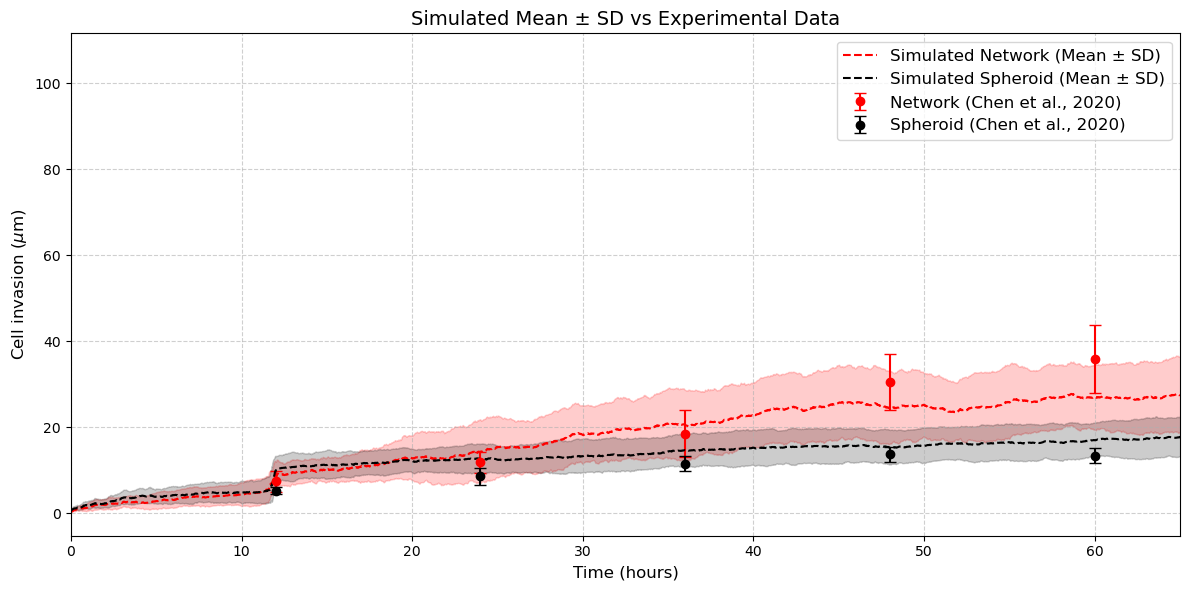

In [31]:
# Updated function: multiply the max distances by 2 before returning
def get_max_distance_per_mcs_scaled(file_paths):
    replicate_data = []
    for path in file_paths:
        df = pd.read_csv(path)
        df_sorted = df.sort_values(['mcs'])
        x0, y0 = df_sorted.iloc[0][['x', 'y']]
        df_sorted['dist_self'] = np.sqrt((df_sorted['x'] - x0)**2 + (df_sorted['y'] - y0)**2)

        # Distance to first replicate's first cell
        ref_df = pd.read_csv(file_paths[0])
        ref_x, ref_y = ref_df.iloc[0][['x', 'y']]
        df_sorted['dist_to_cell1'] = np.sqrt((df_sorted['x'] - ref_x)**2 + (df_sorted['y'] - ref_y)**2)

        df_sorted['max_dist'] = 2 * df_sorted[['dist_self', 'dist_to_cell1']].max(axis=1)
        grouped = df_sorted.groupby('mcs')['max_dist'].max().reset_index().set_index('mcs')
        replicate_data.append(grouped)

    return pd.concat(replicate_data, axis=1)

# Use updated function to compute scaled distances
network_max_df = get_max_distance_per_mcs_scaled(network_files)
spheroid_max_df = get_max_distance_per_mcs_scaled(spheroid_files)

network_mean = network_max_df.mean(axis=1)
network_std = network_max_df.std(axis=1)
network_time = network_mean.index * 0.024

spheroid_mean = spheroid_max_df.mean(axis=1)
spheroid_std = spheroid_max_df.std(axis=1)
spheroid_time = spheroid_mean.index * 0.024

# Replot with scaled distances
plt.figure(figsize=(12, 6))

# Experimental data
plt.errorbar(network_days, network_conc, yerr=network_error, fmt='o', capsize=4, color='red', label='Network (Chen et al., 2020)')
plt.errorbar(spheroid_days, spheroid_conc, yerr=spheroid_error, fmt='o', capsize=4, color='black', label='Spheroid (Chen et al., 2020)')

# Simulated mean ± std (scaled by 2)
plt.plot(network_time, network_mean, color='red', linestyle='--', label='Simulated Network (Mean ± SD)')
plt.fill_between(network_time, network_mean - network_std, network_mean + network_std, color='red', alpha=0.2)

plt.plot(spheroid_time, spheroid_mean, color='black', linestyle='--', label='Simulated Spheroid (Mean ± SD)')
plt.fill_between(spheroid_time, spheroid_mean - spheroid_std, spheroid_mean + spheroid_std, color='black', alpha=0.2)

# Formatting
plt.xlabel('Time (hours)', fontsize=12)
plt.ylabel('Cell invasion ($\mu$m)', fontsize=12)
plt.title('Simulated Mean ± SD vs Experimental Data', fontsize=14)
plt.xlim(0, 65)
plt.legend(loc='best', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("data71.png", dpi=500, bbox_inches='tight')
plt.show()